In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
df = pd.read_csv(
    "synthea-pt150k-lc-data-sel-convert.csv",
    low_memory=False
)

In [3]:
df.shape

(22811, 788)

In [4]:
df["ptnum"].nunique()

22811

In [5]:
df[["label", "scc"]].head()
df["label"].value_counts(normalize=True)

label
0    0.755995
1    0.244005
Name: proportion, dtype: float64

In [6]:
X = df.drop(columns=["ptnum", "label", "scc"])
y = df["label"]

print(X.shape)
print(y.value_counts())

(22811, 785)
label
0    17245
1     5566
Name: count, dtype: int64


In [7]:
# Convert categorical/text columns into numeric dummy columns
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.dtypes.value_counts())

(22811, 142)
bool       96
float64    46
Name: count, dtype: int64


In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [9]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

# Best parameters
print("Random Forest Best Params:", grid_rf.best_params_)

# Best model
best_rf = grid_rf.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest Accuracy: 0.9428696668614845
Random Forest ROC-AUC: 0.979756277935046
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      5174
           1       0.93      0.83      0.88      1670

    accuracy                           0.94      6844
   macro avg       0.94      0.90      0.92      6844
weighted avg       0.94      0.94      0.94      6844



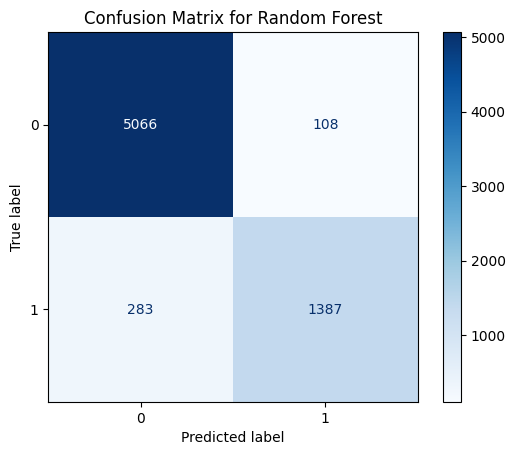

In [10]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Random Forest")
plt.show()

In [11]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(20))

C-424144002_gt70     0.133437
C-263495000_m        0.132574
C-2069-3_normal      0.043693
C-424144002_50t70    0.043692
C-20565-8_normal     0.039104
C-72166-2_never      0.031029
C-1920-8_normal      0.027475
C-2857-1_normal      0.026662
C-789-8_normal       0.026272
C-4544-3_normal      0.021108
C-2028-9_normal      0.018565
C-89579-7_normal     0.017744
C-1751-7_normal      0.017522
C-21000-5_normal     0.016555
C-718-7_normal       0.016023
C-788-0_normal       0.015237
C-2345-7_normal      0.015081
C-785-6_normal       0.015051
C-46288-7_normal     0.013162
C-38483-4_normal     0.012547
dtype: float64


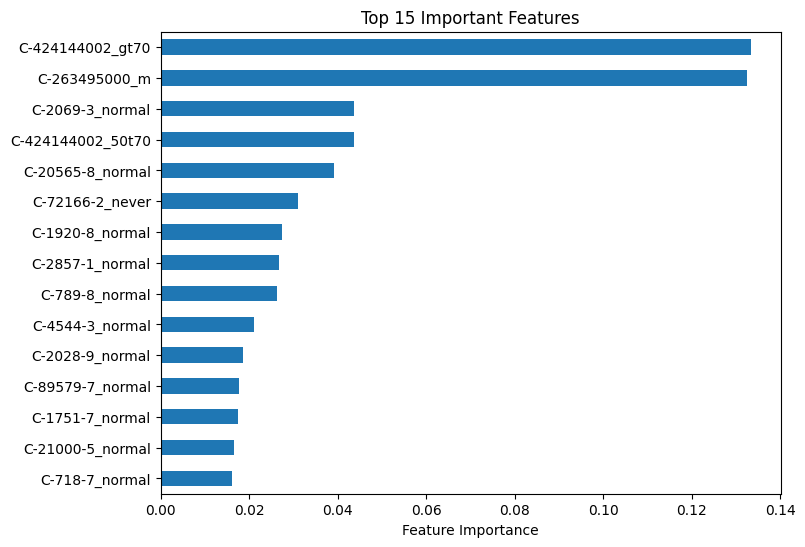

In [12]:
feature_importance.head(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.xlabel("Feature Importance")
plt.show()

In [13]:
# Train/test split
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=4,
    stratify=y
)

# Impute missing values
imputer = SimpleImputer(strategy="most_frequent")
X_train_imp = imputer.fit_transform(X_train1)
X_test_imp = imputer.transform(X_test1)

# Scale
scaler1 = MinMaxScaler()
X_train2 = scaler1.fit_transform(X_train_imp)
X_test2 = scaler1.transform(X_test_imp)

# Logistic regression
lrn = LogisticRegression(max_iter=2000)
lrn.fit(X_train2, y_train1)

# Predict on the SCALED data
y_train_pred1 = lrn.predict(X_train2)
y_pred1 = lrn.predict(X_test2)
y_prob1 = lrn.predict_proba(X_test2)[:, 1]

# Metrics
train_accuracy = accuracy_score(y_train1, y_train_pred1)
test_accuracy = accuracy_score(y_test1, y_pred1)
error = 1 - test_accuracy

print("Logistic Regression training accuracy:", train_accuracy)
print("Logistic Regression test error rate:", error)
print("Logistic Regression accuracy:", test_accuracy)
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test1, y_prob1))
print(classification_report(y_test1, y_pred1))

C:\Users\denis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['C-1191222' 'C-190905008' 'C-198767' 'C-205532' 'C-232657004'
 'C-288328004' 'C-313572' 'C-406602003' 'C-427089005' 'C-444260001'
 'C-448417001' 'C-48387007' 'C-707418001' 'C-86964003']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
C:\Users\denis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['C-1191222' 'C-190905008' 'C-198767' 'C-205532' 'C-232657004'
 'C-288328004' 'C-313572' 'C-406602003' 'C-427089005' 'C-444260001'
 'C-448417001' 'C-48387007' 'C-707418001' 'C-86964003']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Logistic Regression training accuracy: 0.9342393686979396
Logistic Regression test error rate: 0.06618452772298922
Logistic Regression accuracy: 0.9338154722770108
Logistic Regression ROC-AUC: 0.9755586806776306
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      3450
           1       0.91      0.81      0.86      1113

    accuracy                           0.93      4563
   macro avg       0.93      0.89      0.91      4563
weighted avg       0.93      0.93      0.93      4563



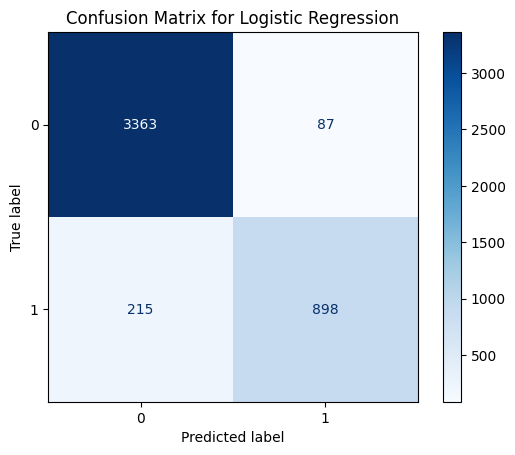

In [14]:
cm = confusion_matrix(y_test1, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

In [15]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("XGBoost Best Params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Best Params: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
XGBoost Accuracy: 0.9488603156049094
XGBoost ROC-AUC: 0.9832790738584679
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5174
           1       0.93      0.86      0.89      1670

    accuracy                           0.95      6844
   macro avg       0.94      0.92      0.93      6844
weighted avg       0.95      0.95      0.95      6844



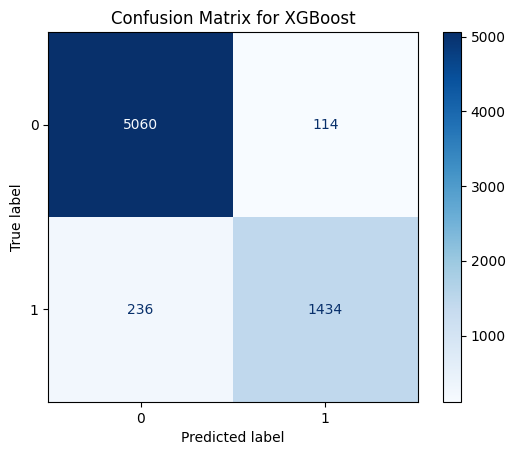

In [16]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for XGBoost")
plt.show()

In [17]:
param_grid_lgbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 10, 20]
}

lgbm = LGBMClassifier(random_state=42)

grid_lgbm = GridSearchCV(
    lgbm,
    param_grid_lgbm,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train)

print("LightGBM Best Params:", grid_lgbm.best_params_)

best_lgbm = grid_lgbm.best_estimator_

y_pred_lgbm = best_lgbm.predict(X_test)
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("LightGBM ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 3896, number of negative: 12071
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3261
[LightGBM] [Info] Number of data points in the train set: 15967, number of used features: 125
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.244003 -> initscore=-1.130855
[LightGBM] [Info] Start training from score -1.130855
LightGBM Best Params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}
LightGBM Accuracy: 0.9484219754529515
LightGBM ROC-AUC: 0.9817675433825044
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5174
           1       0.92      0.86      0.89      1670

    accuracy                           0.95      6844
   macro avg       0.94      0.92      0.93     

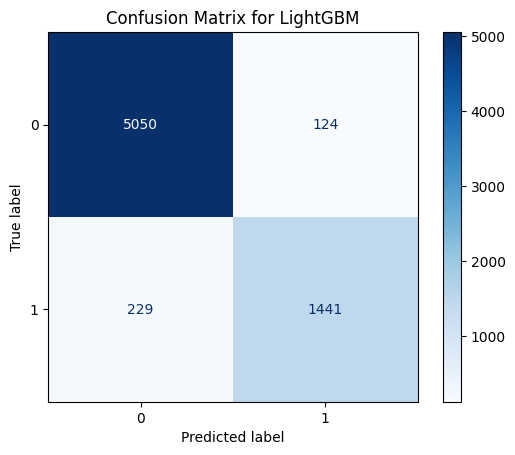

In [18]:
cm = confusion_matrix(y_test, y_pred_lgbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for LightGBM")
plt.show()

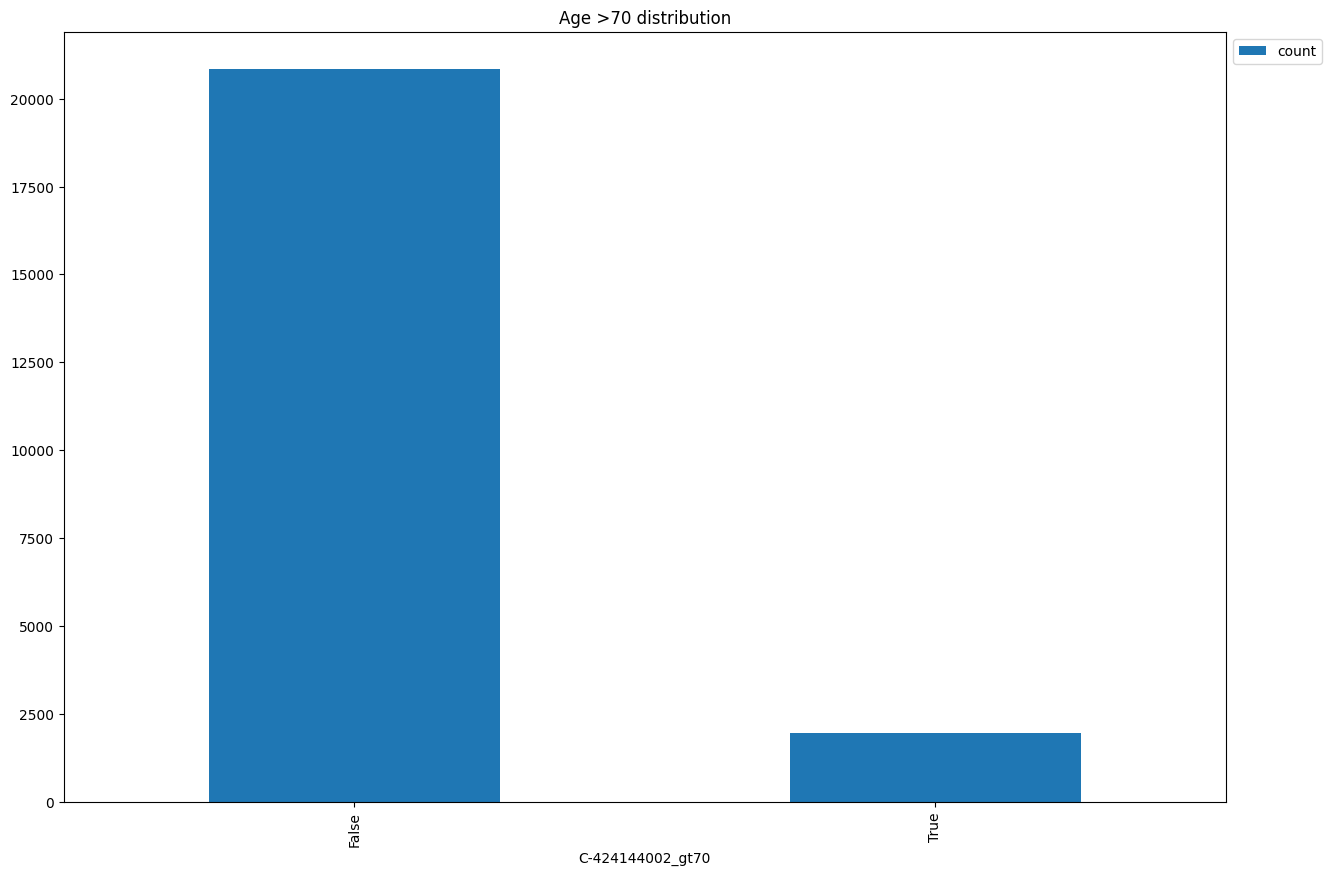

In [19]:
Over70Plot = X['C-424144002_gt70'].value_counts().plot(
    kind='bar',
    title="Age >70 distribution",
    figsize=(15,10)
)

Over70Plot.legend(loc='upper left', bbox_to_anchor=(1,1))

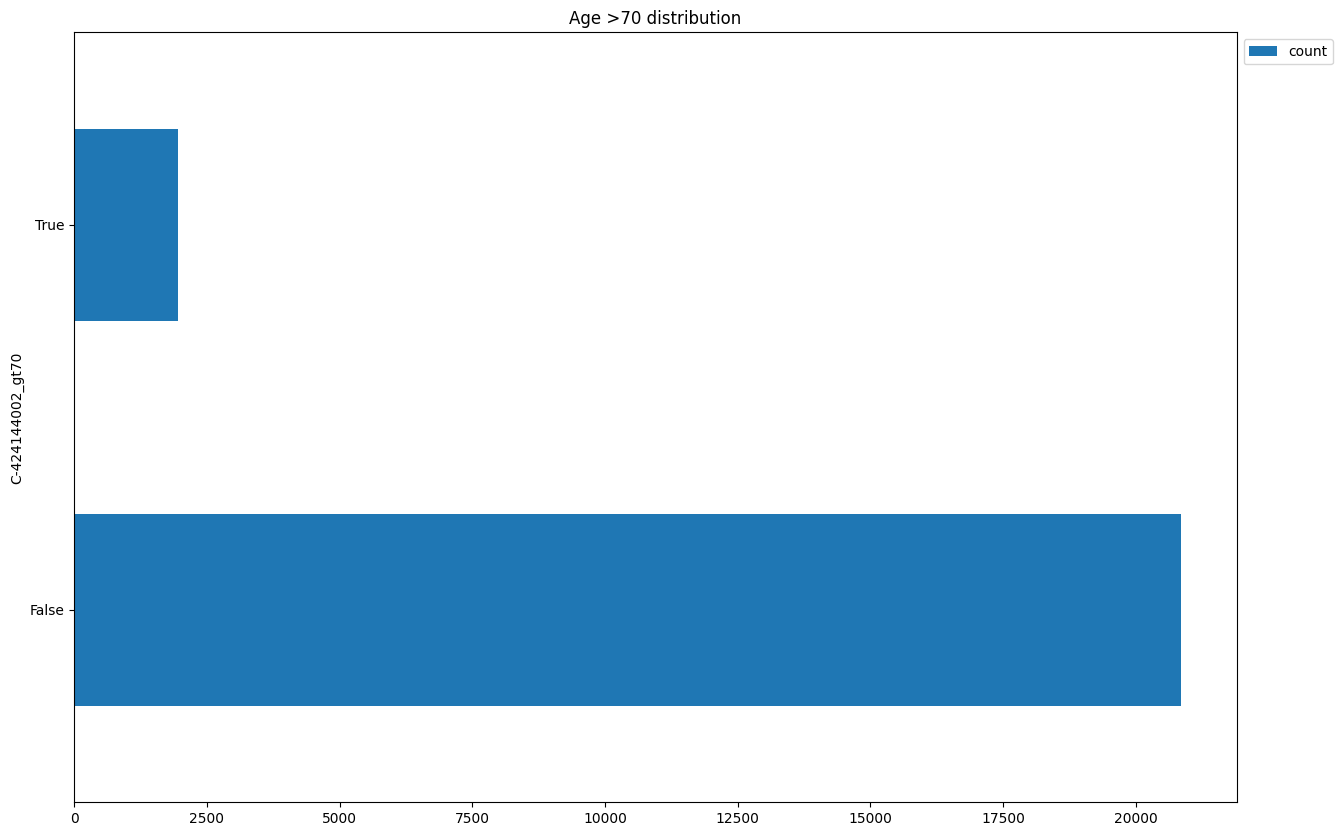

In [20]:
Over70Plot1 = X['C-424144002_gt70'].value_counts().plot(
    kind='barh',
    title="Age >70 distribution",
    figsize=(15,10)
)

Over70Plot1.legend(loc='upper left', bbox_to_anchor=(1,1))

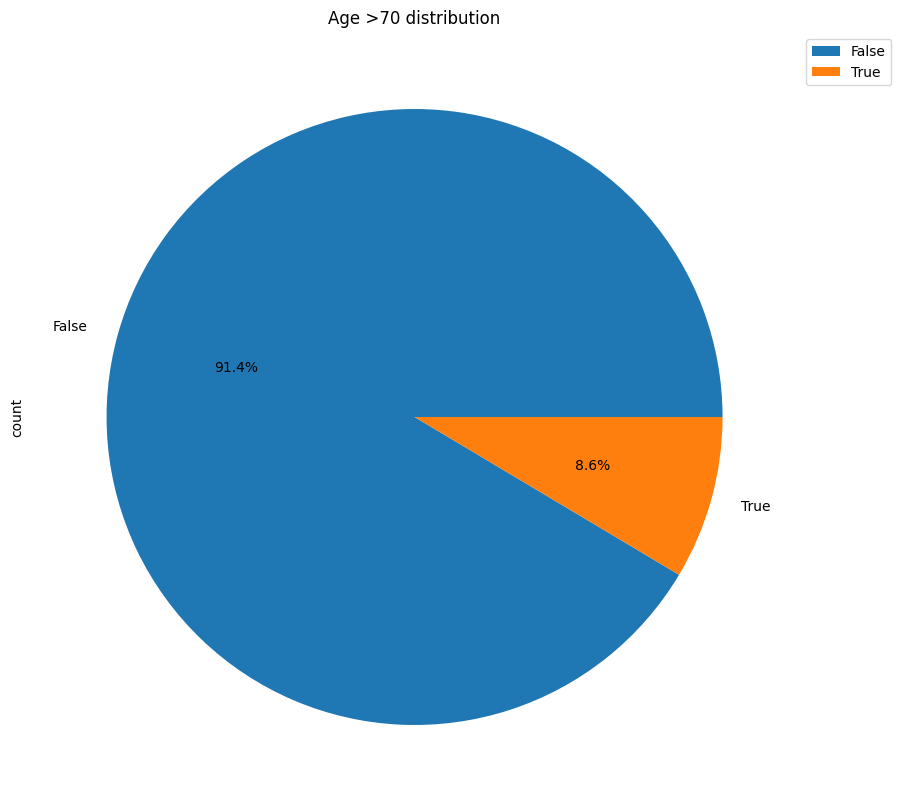

In [21]:
Over70Plot1 = X['C-424144002_gt70'].value_counts().plot(
    kind='pie',
    title="Age >70 distribution",
    autopct='%1.1f%%',
    figsize=(15,10)
)

Over70Plot1.legend(loc='upper left', bbox_to_anchor=(1,1))

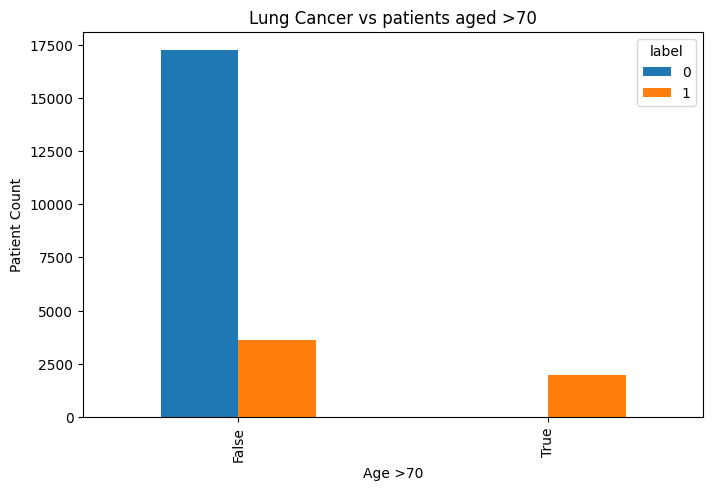

In [22]:
# Shows whether patients >70 have higher cancer prevalence
pd.crosstab(
    X['C-424144002_gt70'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs patients aged >70")
plt.xlabel("Age >70")
plt.ylabel("Patient Count")
plt.show()

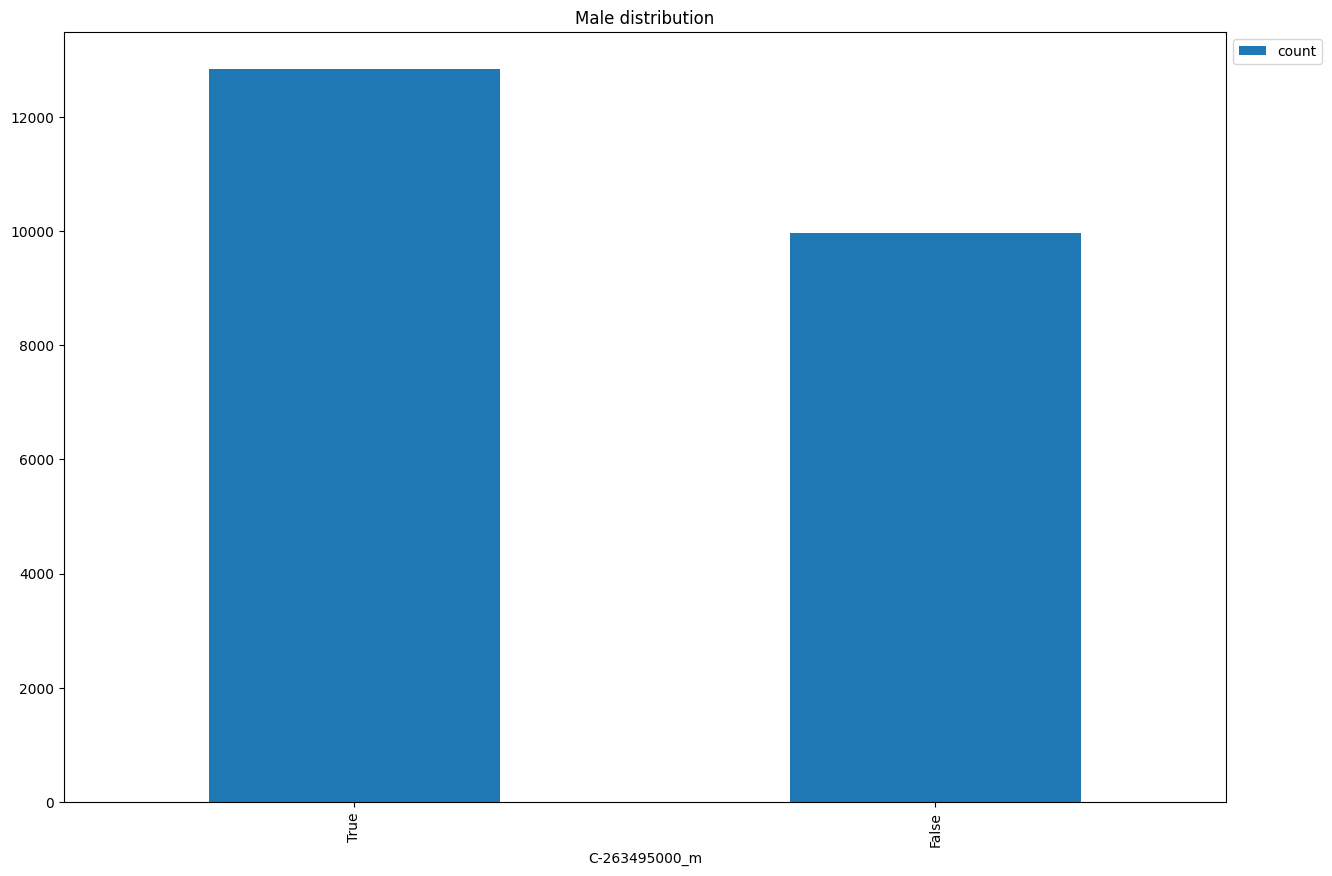

In [23]:
isMalePlot = X['C-263495000_m'].value_counts().plot(
    kind='bar',
    title="Male distribution",
    figsize=(15,10)
)

isMalePlot.legend(loc='upper left', bbox_to_anchor=(1,1))

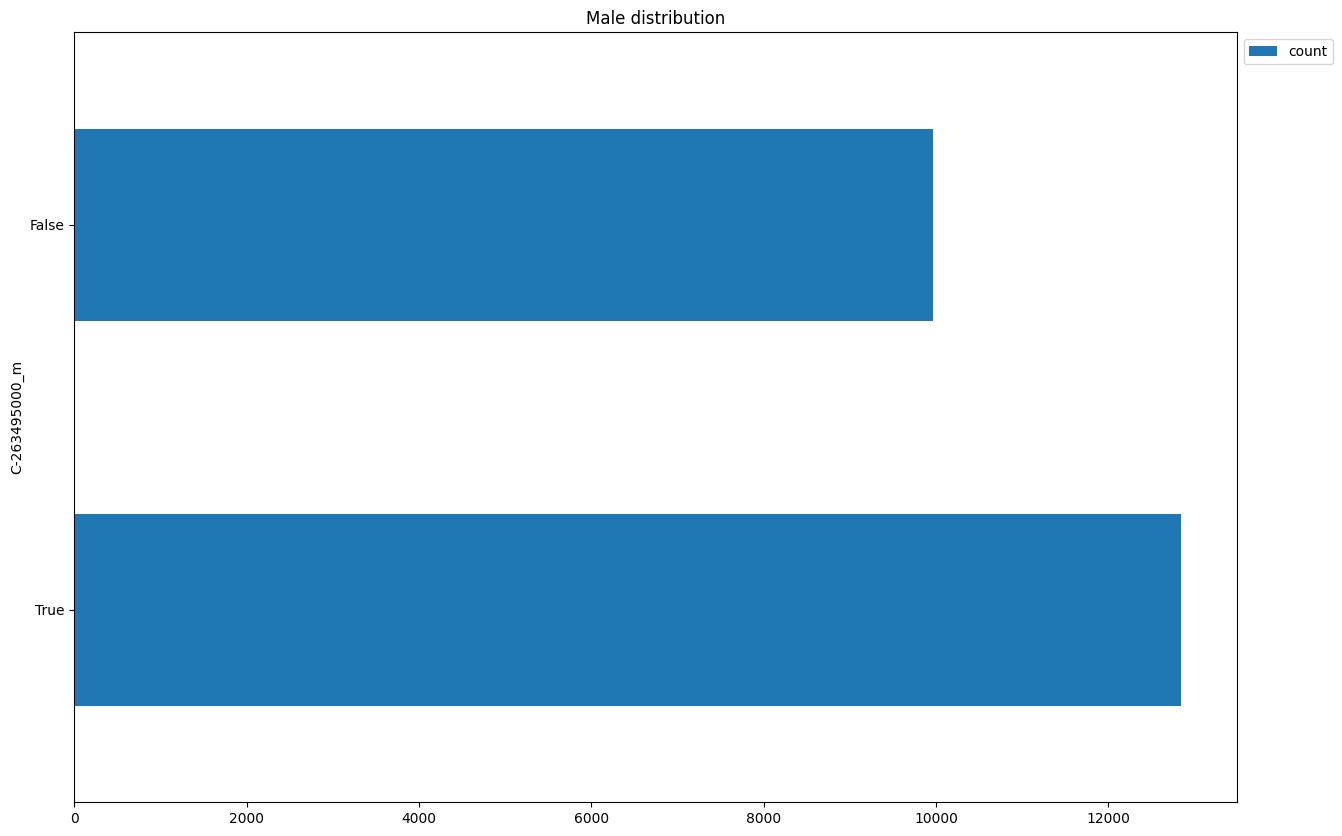

In [24]:
isMalePlot = X['C-263495000_m'].value_counts().plot(
    kind='barh',
    title="Male distribution",
    figsize=(15,10)
)

isMalePlot.legend(loc='upper left', bbox_to_anchor=(1,1))

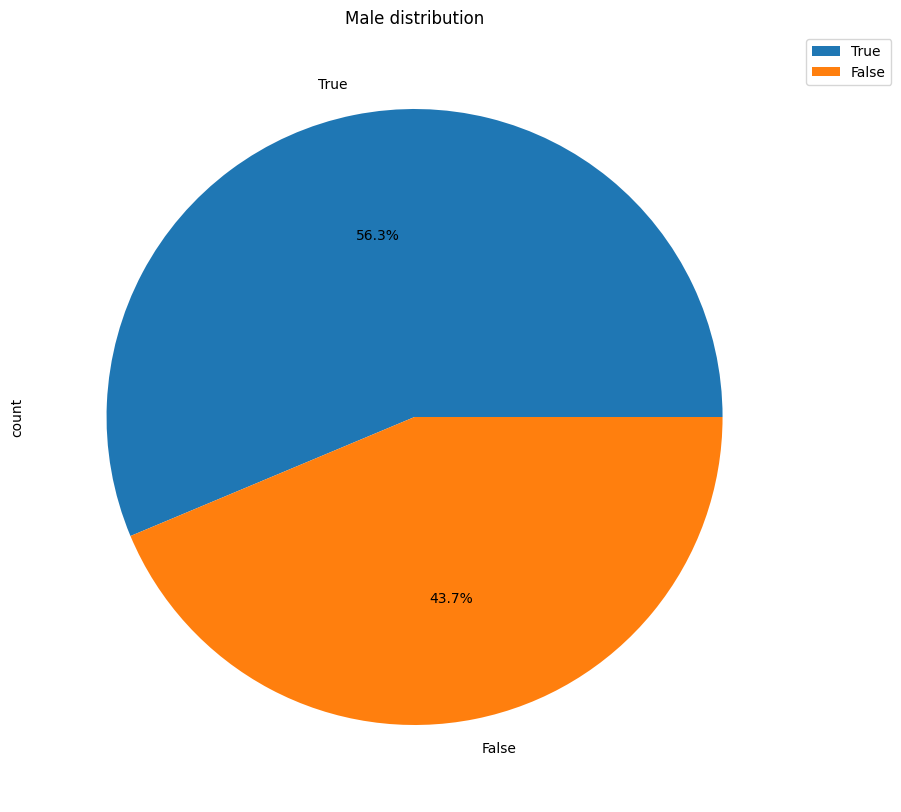

In [25]:
isMalePlot = X['C-263495000_m'].value_counts().plot(
    kind='pie',
    title="Male distribution",
    autopct='%1.1f%%',
    figsize=(15,10)
)

isMalePlot.legend(loc='upper left', bbox_to_anchor=(1,1))


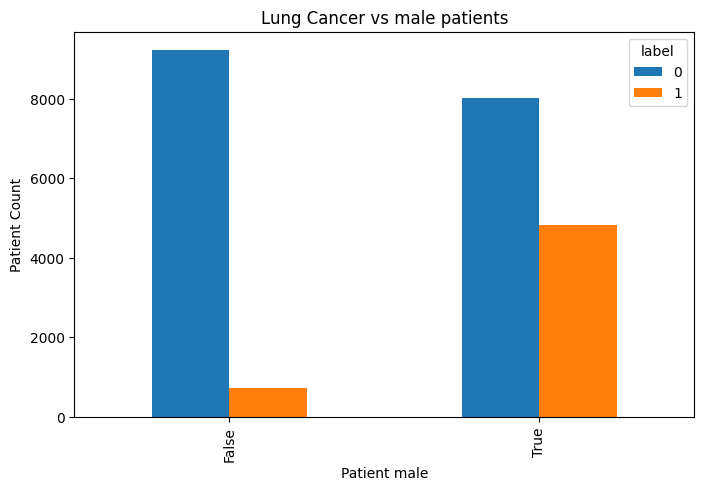

In [26]:
pd.crosstab(
    X['C-263495000_m'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs male patients")
plt.xlabel("Patient male")
plt.ylabel("Patient Count")
plt.show()

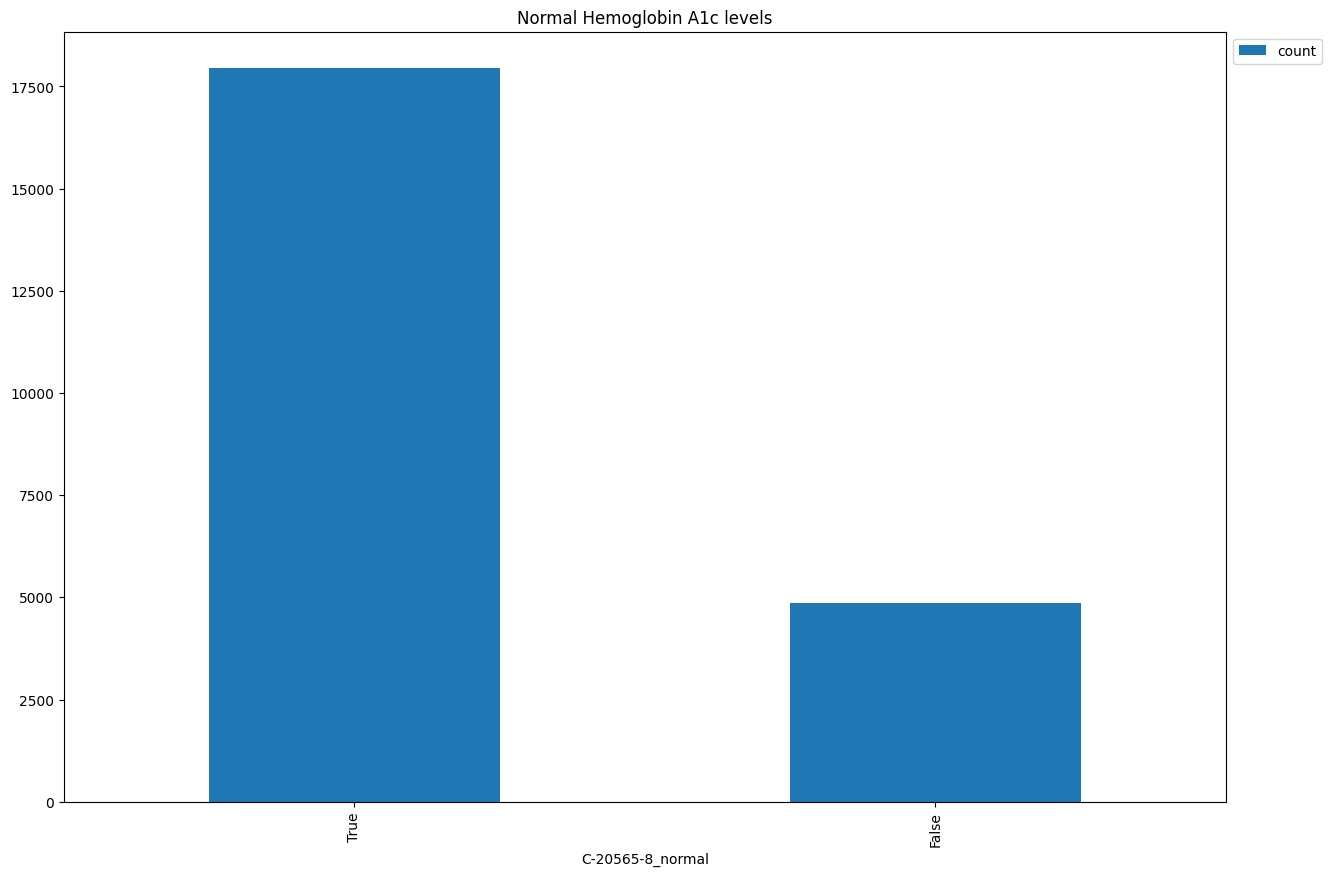

In [27]:
hemo1ACLvl = X['C-20565-8_normal'].value_counts().plot(
    kind='bar',
    title="Normal Hemoglobin A1c levels",
    figsize=(15,10)
)

hemo1ACLvl.legend(loc='upper left', bbox_to_anchor=(1,1))

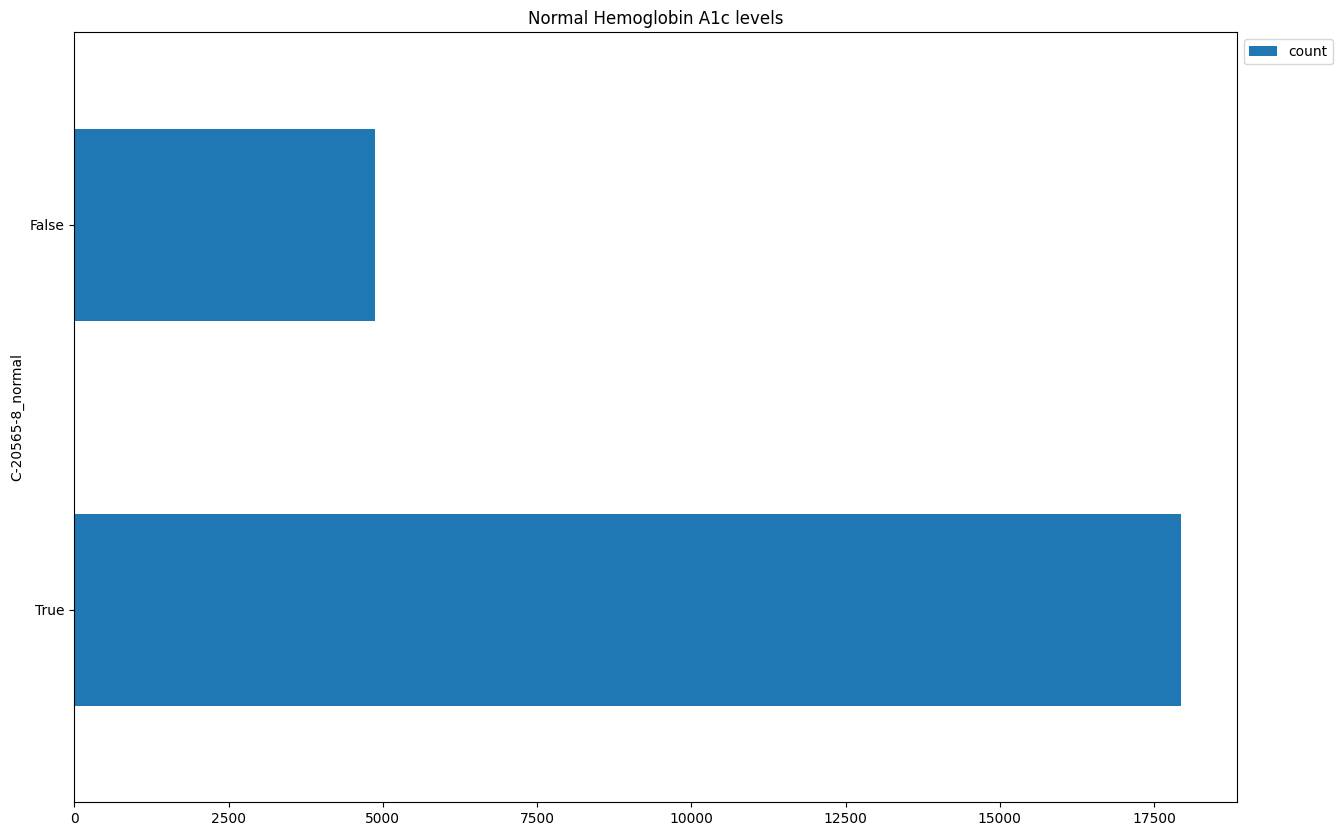

In [28]:
hemo1ACLvl = X['C-20565-8_normal'].value_counts().plot(
    kind='barh',
    title="Normal Hemoglobin A1c levels",
    figsize=(15,10)
)

hemo1ACLvl.legend(loc='upper left', bbox_to_anchor=(1,1))

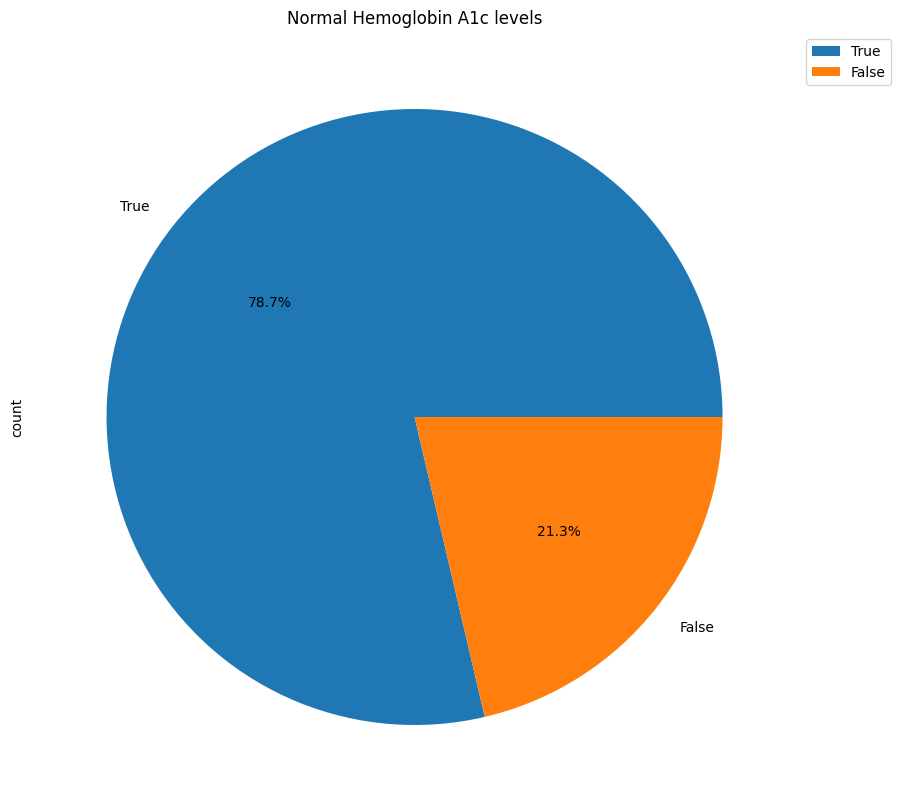

In [29]:
hemo1ACLvl = X['C-20565-8_normal'].value_counts().plot(
    kind='pie',
    title="Normal Hemoglobin A1c levels",
    autopct='%1.1f%%',
    figsize=(15,10)
)

hemo1ACLvl.legend(loc='upper left', bbox_to_anchor=(1,1))


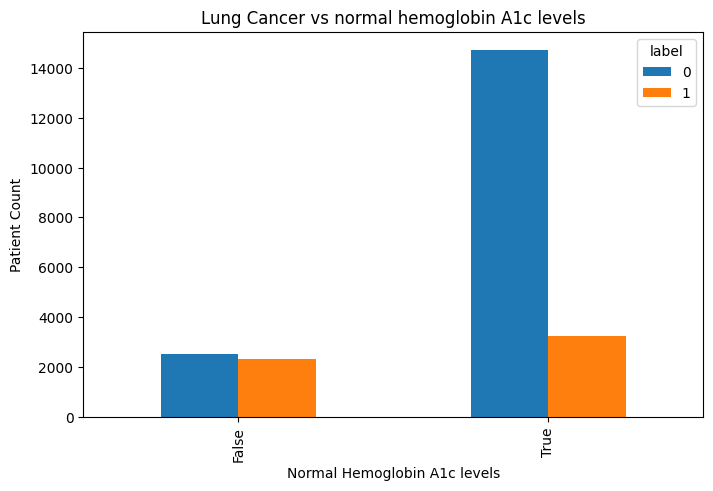

In [30]:
pd.crosstab(
    X['C-20565-8_normal'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs normal hemoglobin A1c levels")
plt.xlabel("Normal Hemoglobin A1c levels")
plt.ylabel("Patient Count")
plt.show()

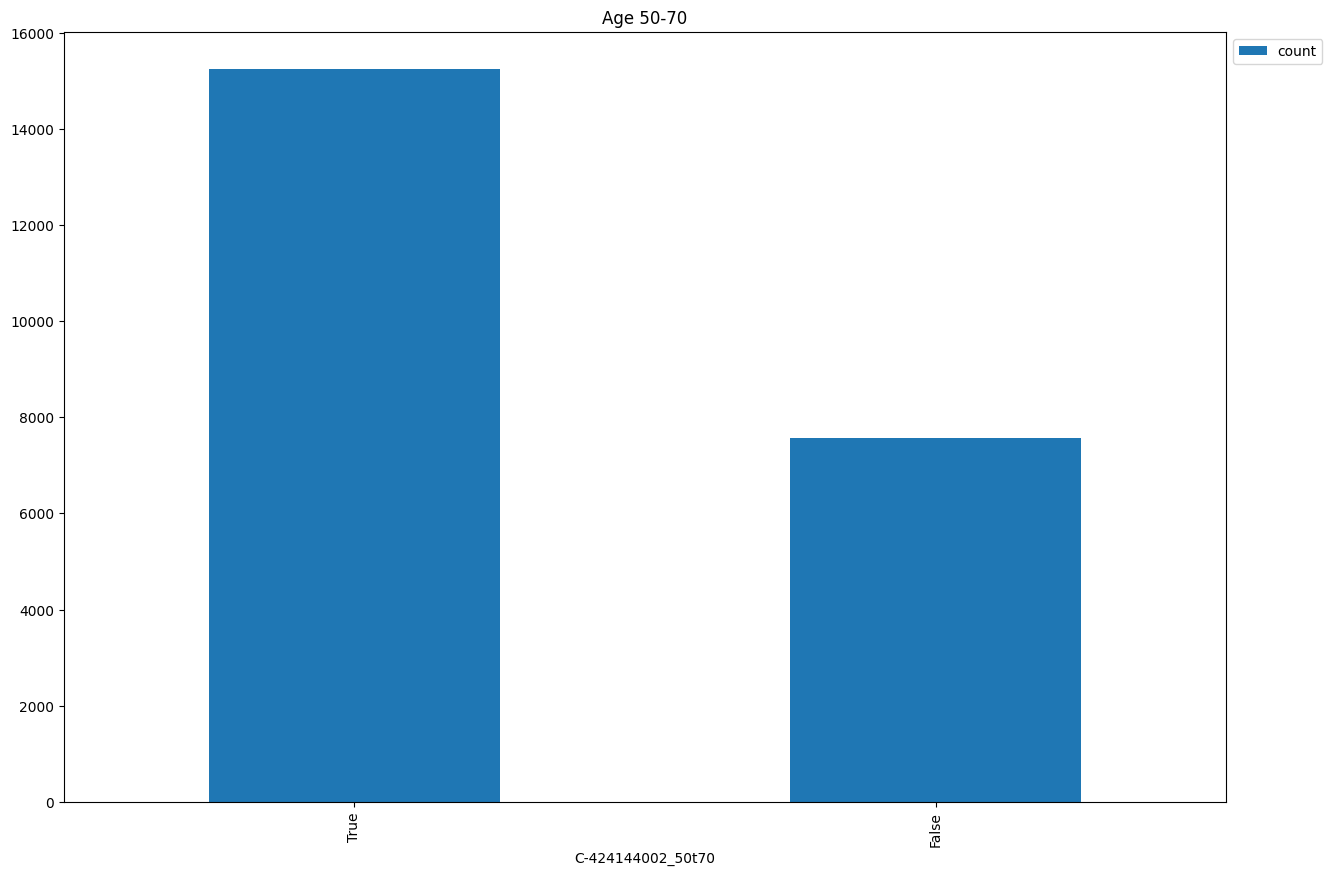

In [31]:
fifToSev = X['C-424144002_50t70'].value_counts().plot(
    kind='bar',
    title="Age 50-70",
    figsize=(15,10)
)

fifToSev.legend(loc='upper left', bbox_to_anchor=(1,1))

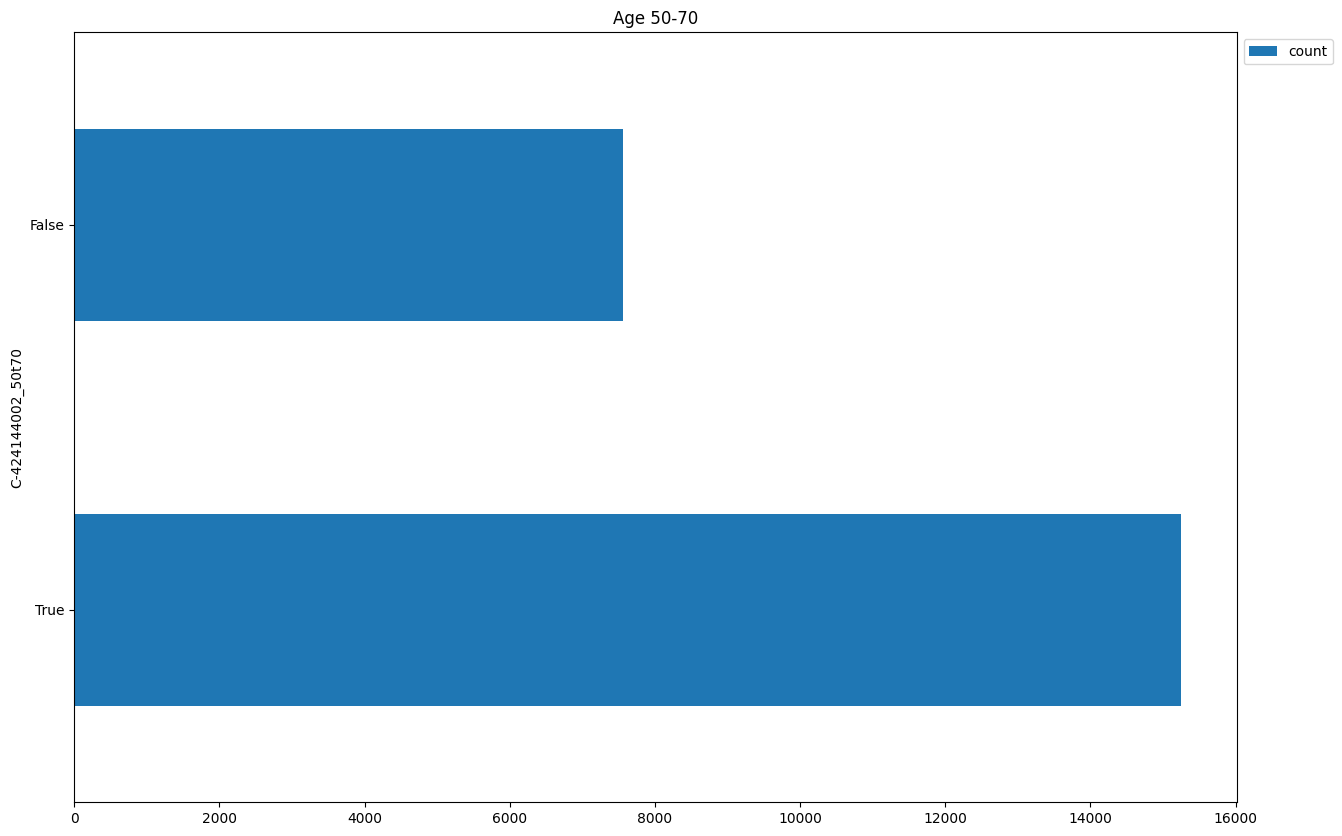

In [32]:
fifToSev = X['C-424144002_50t70'].value_counts().plot(
    kind='barh',
    title="Age 50-70",
    figsize=(15,10)
)

fifToSev.legend(loc='upper left', bbox_to_anchor=(1,1))

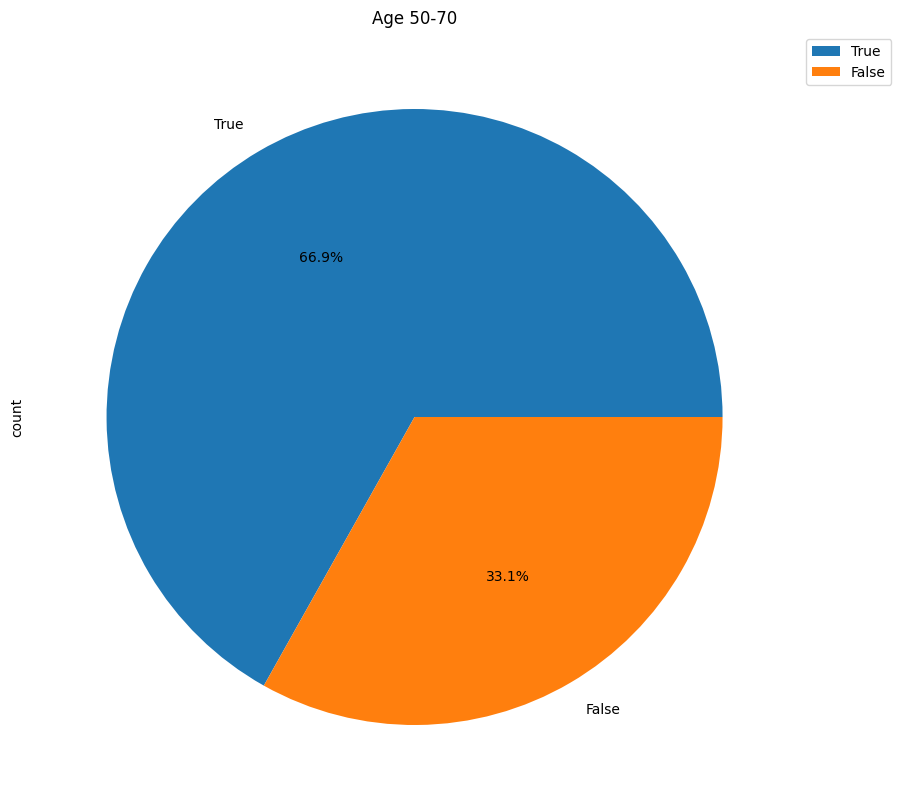

In [33]:
fifToSev = X['C-424144002_50t70'].value_counts().plot(
    kind='pie',
    title="Age 50-70",
    autopct='%1.1f%%',
    figsize=(15,10)
)

fifToSev.legend(loc='upper left', bbox_to_anchor=(1,1))

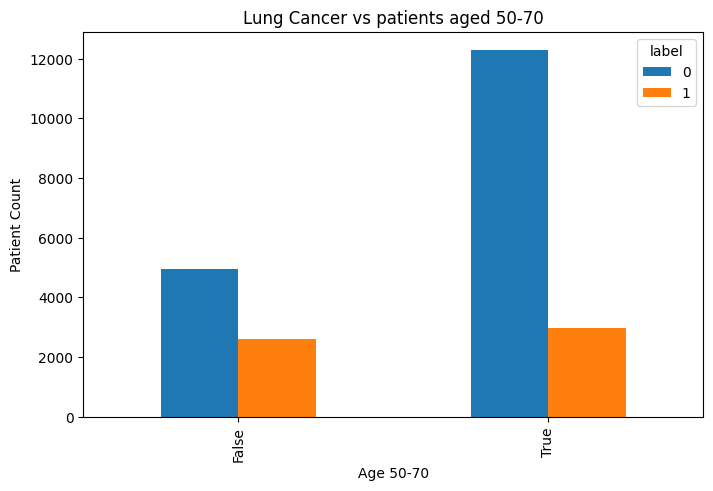

In [34]:
pd.crosstab(
    X['C-424144002_50t70'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs patients aged 50-70")
plt.xlabel("Age 50-70")
plt.ylabel("Patient Count")
plt.show()

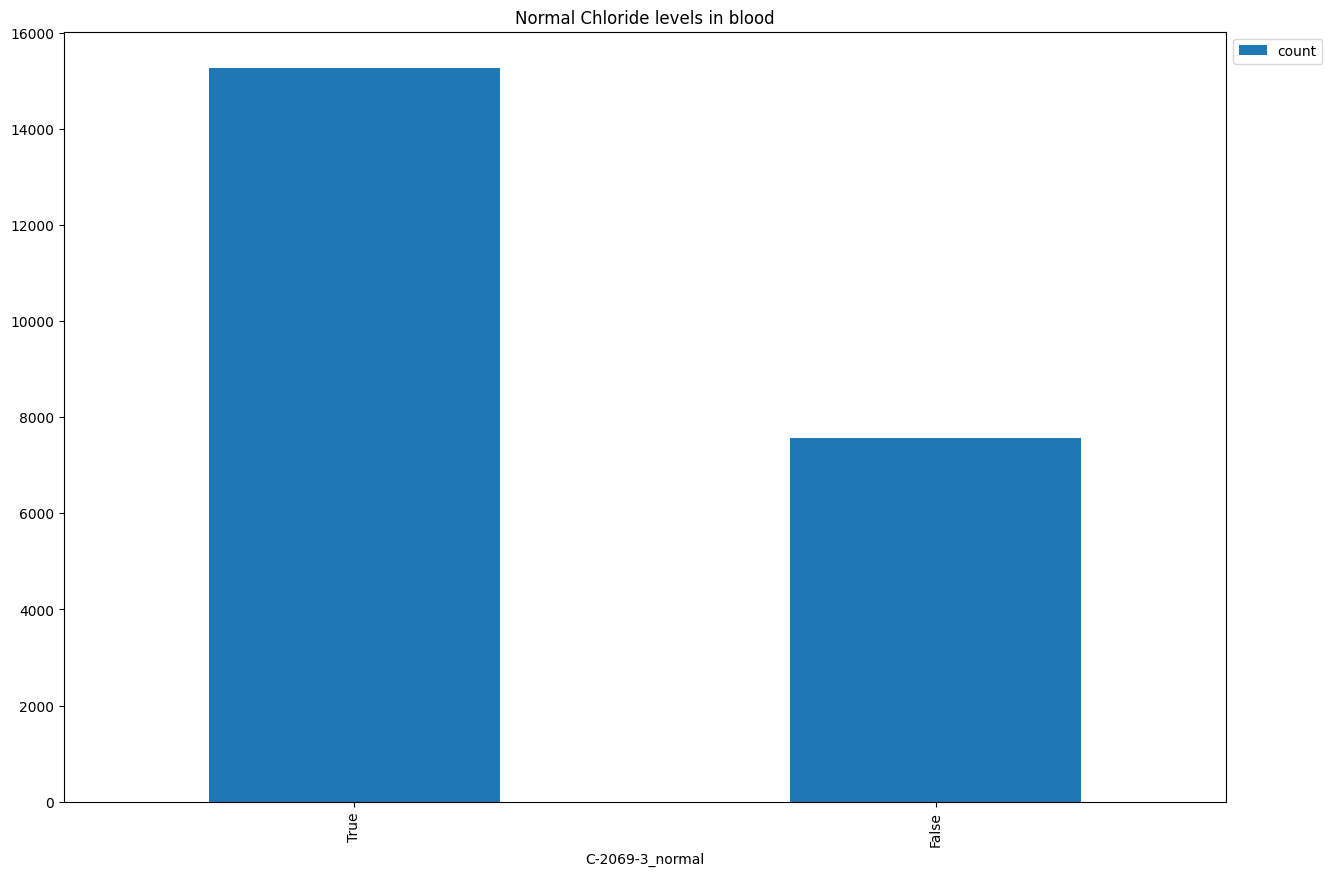

In [35]:
chlLvl = X['C-2069-3_normal'].value_counts().plot(
    kind='bar',
    title="Normal Chloride levels in blood",
    figsize=(15,10)
)

chlLvl.legend(loc='upper left', bbox_to_anchor=(1,1))

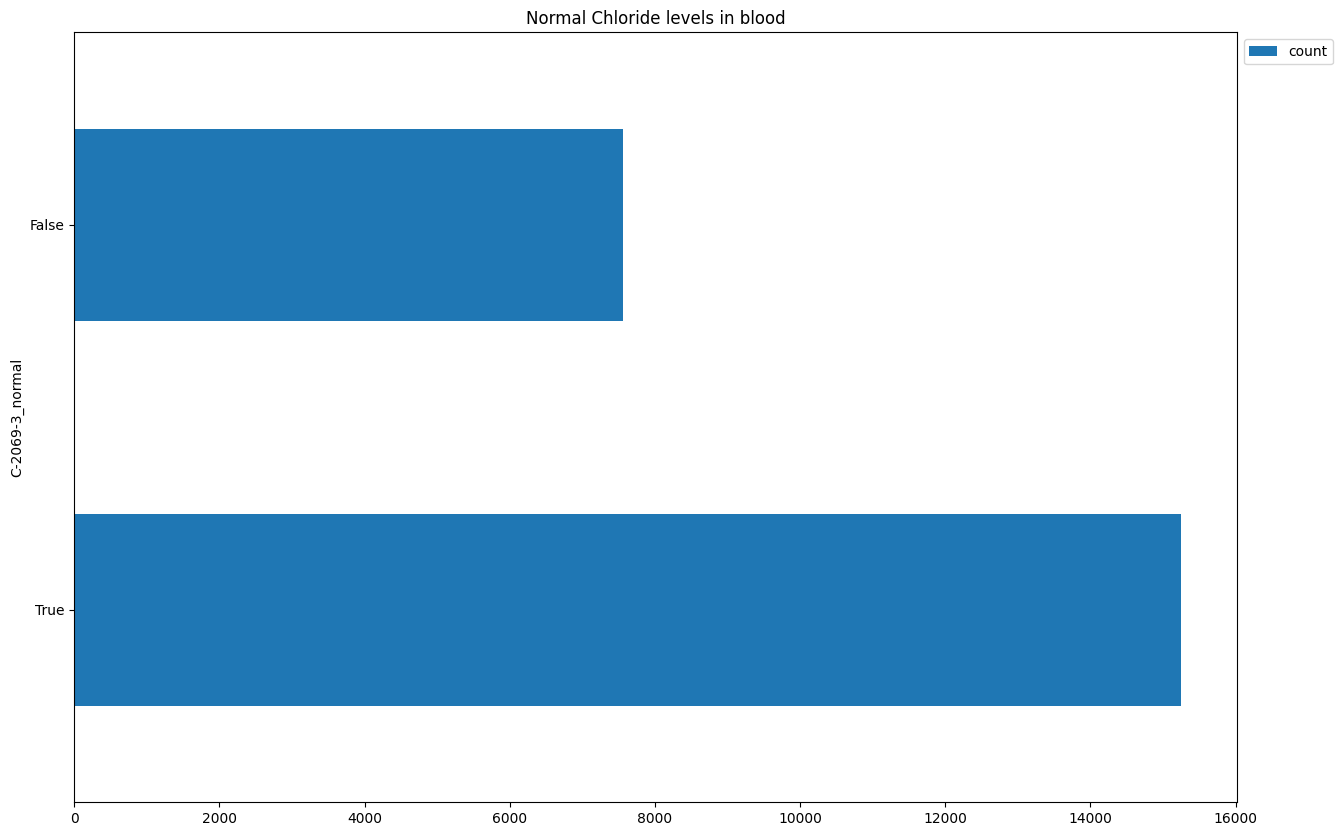

In [36]:
chlLvl = X['C-2069-3_normal'].value_counts().plot(
    kind='barh',
    title="Normal Chloride levels in blood",
    figsize=(15,10)
)

chlLvl.legend(loc='upper left', bbox_to_anchor=(1,1))

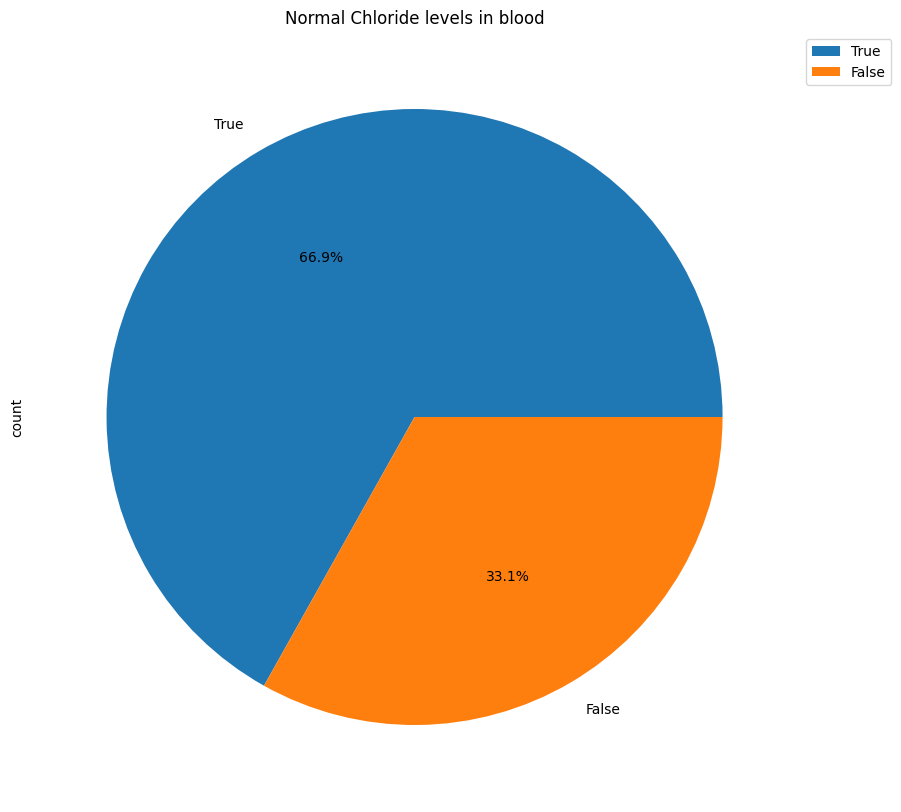

In [37]:
chlLvl = X['C-2069-3_normal'].value_counts().plot(
    kind='pie',
    title="Normal Chloride levels in blood",
    autopct='%1.1f%%',
    figsize=(15,10)
)

chlLvl.legend(loc='upper left', bbox_to_anchor=(1,1))

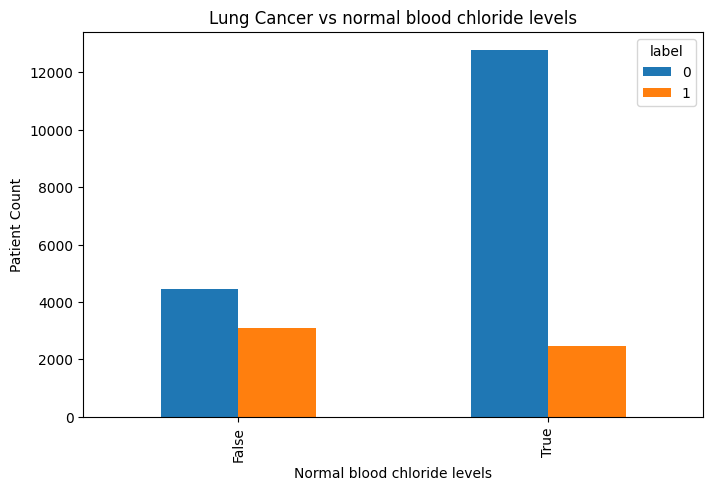

In [38]:
pd.crosstab(
    X['C-2069-3_normal'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs normal blood chloride levels")
plt.xlabel("Normal blood chloride levels")
plt.ylabel("Patient Count")
plt.show()

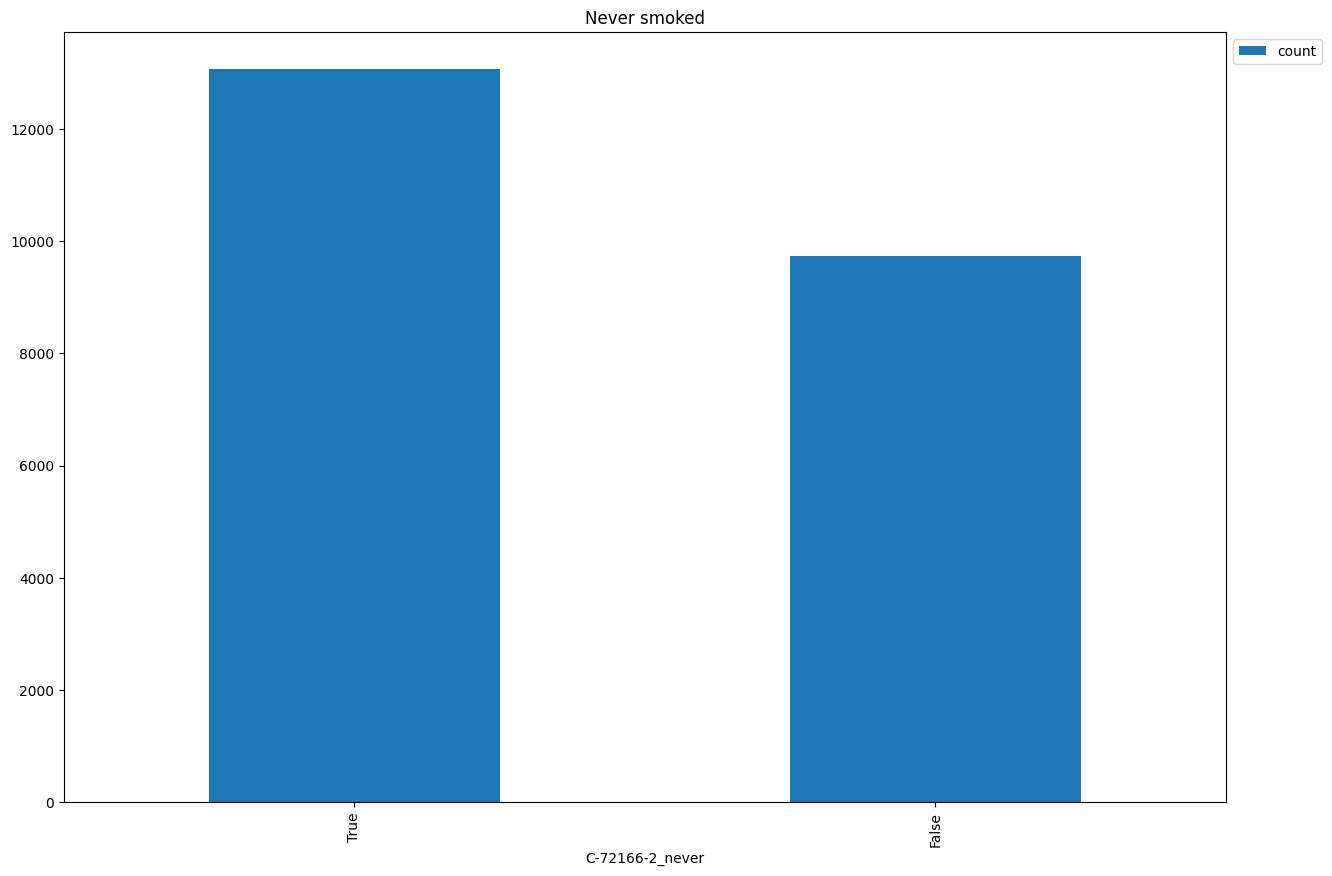

In [39]:
nSmoke = X['C-72166-2_never'].value_counts().plot(
    kind='bar',
    title="Never smoked",
    figsize=(15,10)
)

nSmoke.legend(loc='upper left', bbox_to_anchor=(1,1))

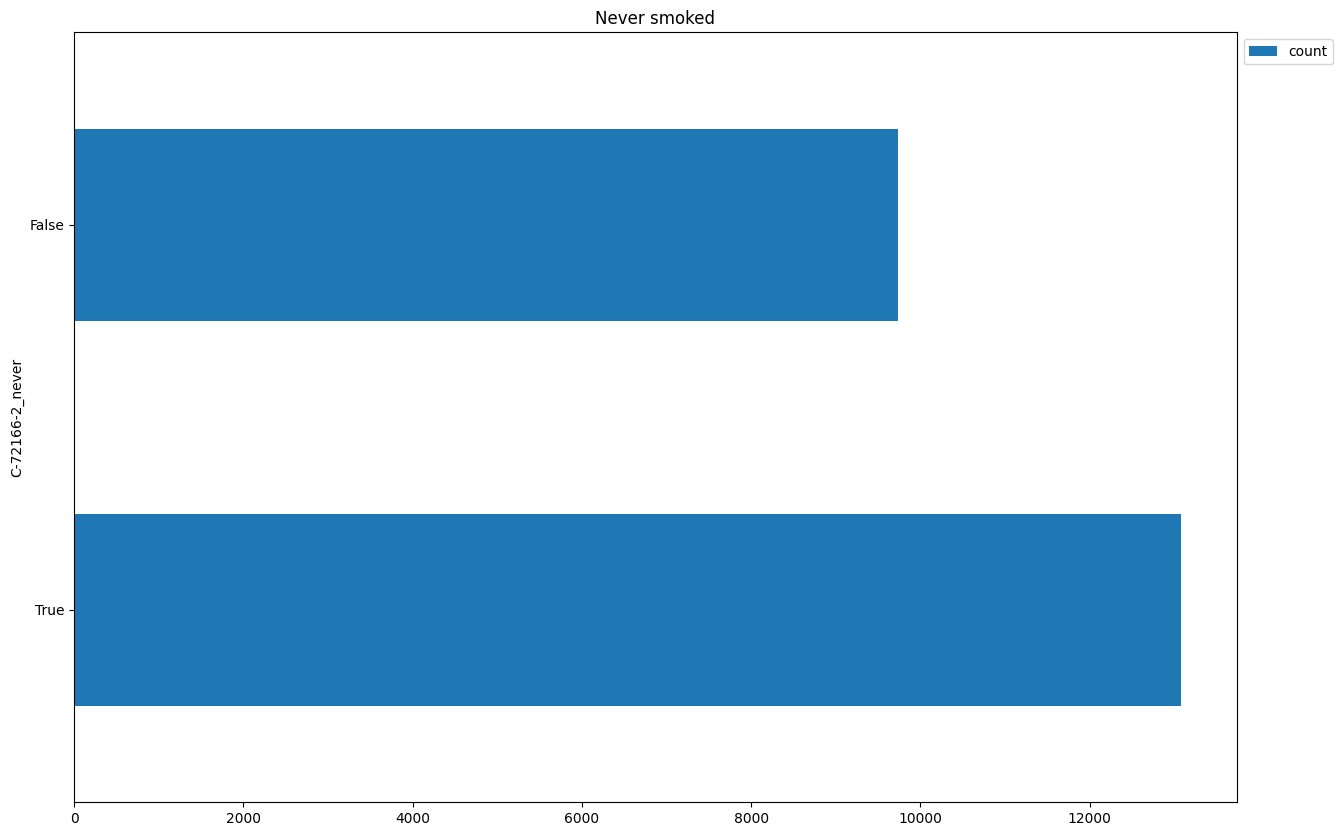

In [40]:
nSmoke = X['C-72166-2_never'].value_counts().plot(
    kind='barh',
    title="Never smoked",
    figsize=(15,10)
)

nSmoke.legend(loc='upper left', bbox_to_anchor=(1,1))

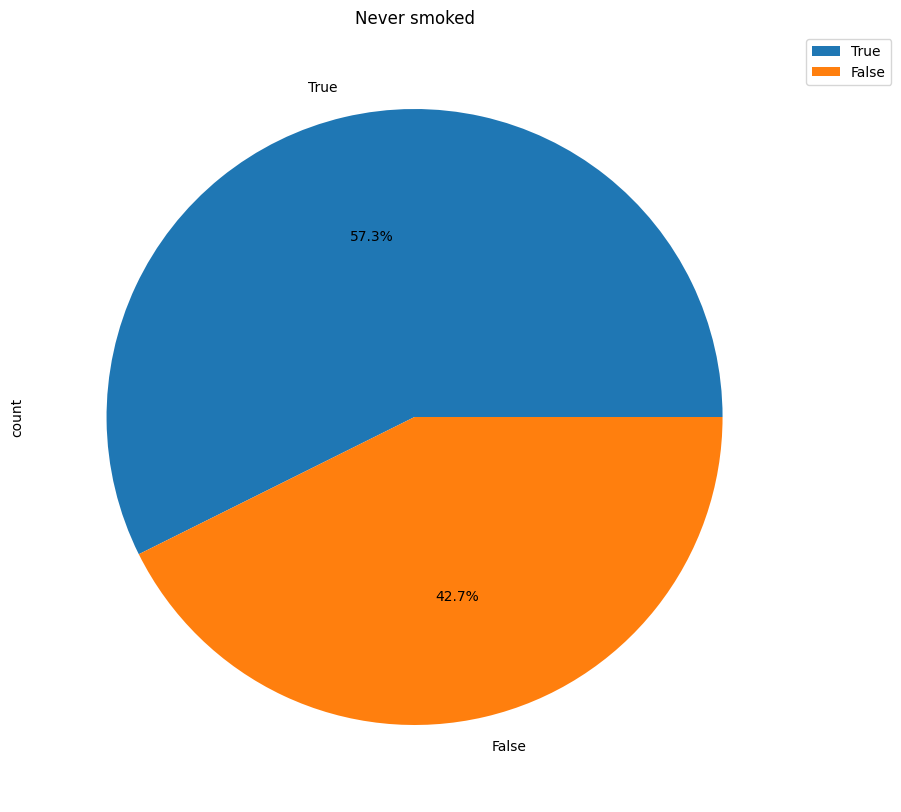

In [41]:
nSmoke = X['C-72166-2_never'].value_counts().plot(
    kind='pie',
    title="Never smoked",
    autopct='%1.1f%%',
    figsize=(15,10)
)

nSmoke.legend(loc='upper left', bbox_to_anchor=(1,1))

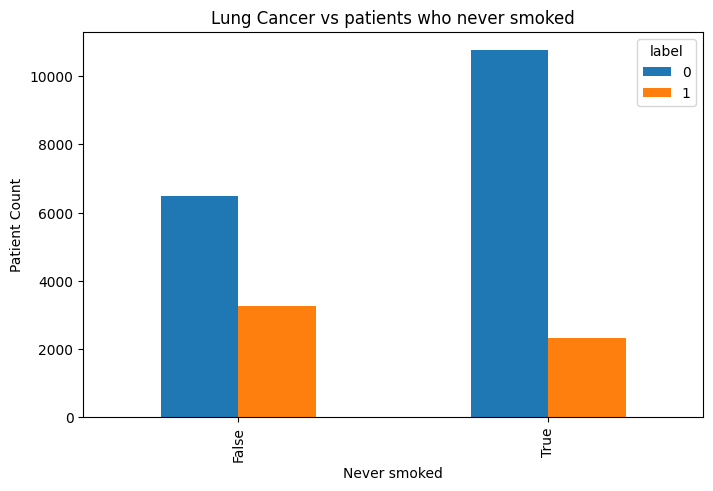

In [42]:
pd.crosstab(
    X['C-72166-2_never'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs patients who never smoked")
plt.xlabel("Never smoked")
plt.ylabel("Patient Count")
plt.show()

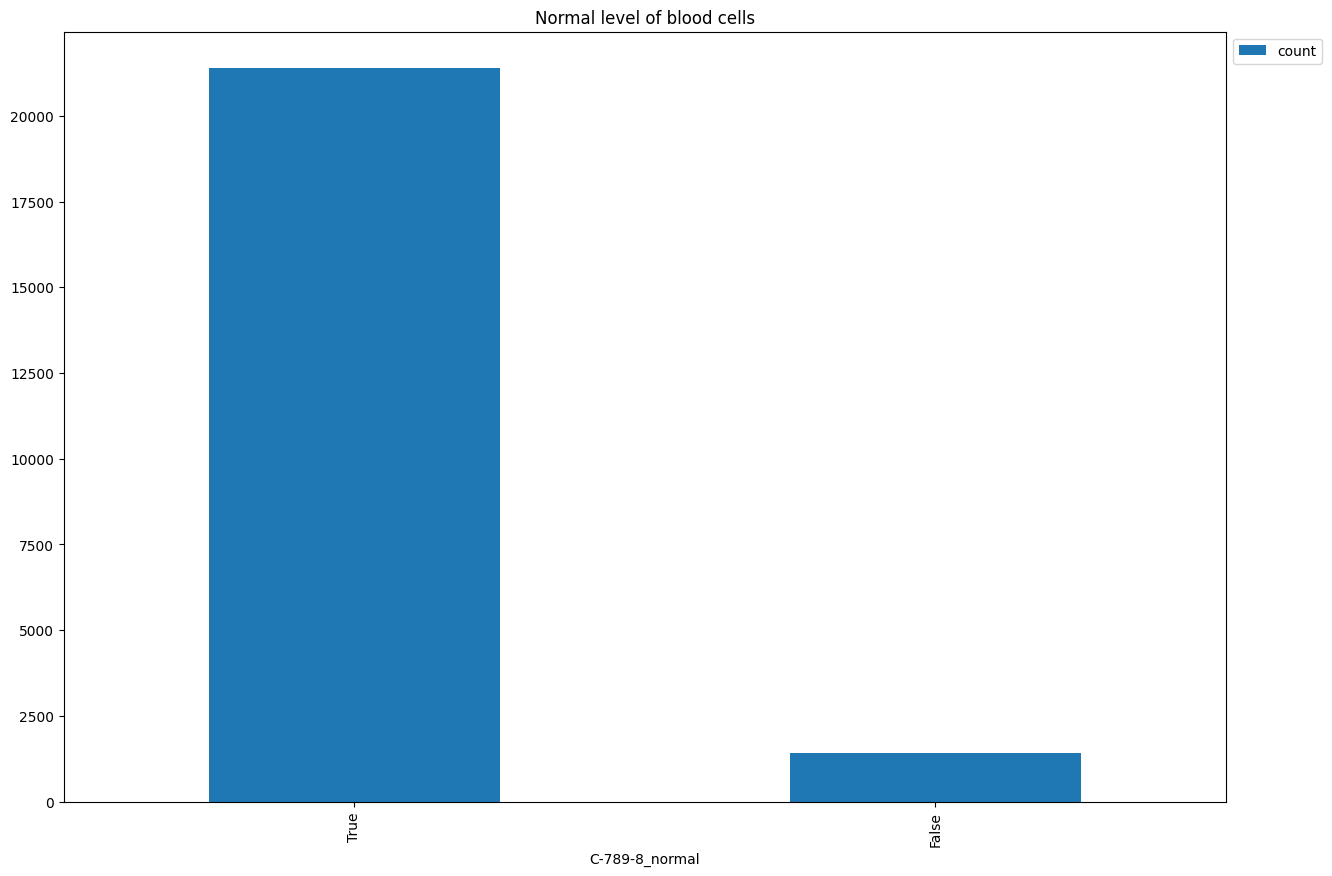

In [43]:
blCellNorm = X['C-789-8_normal'].value_counts().plot(
    kind='bar',
    title="Normal level of blood cells",
    figsize=(15,10)
)

blCellNorm.legend(loc='upper left', bbox_to_anchor=(1,1))

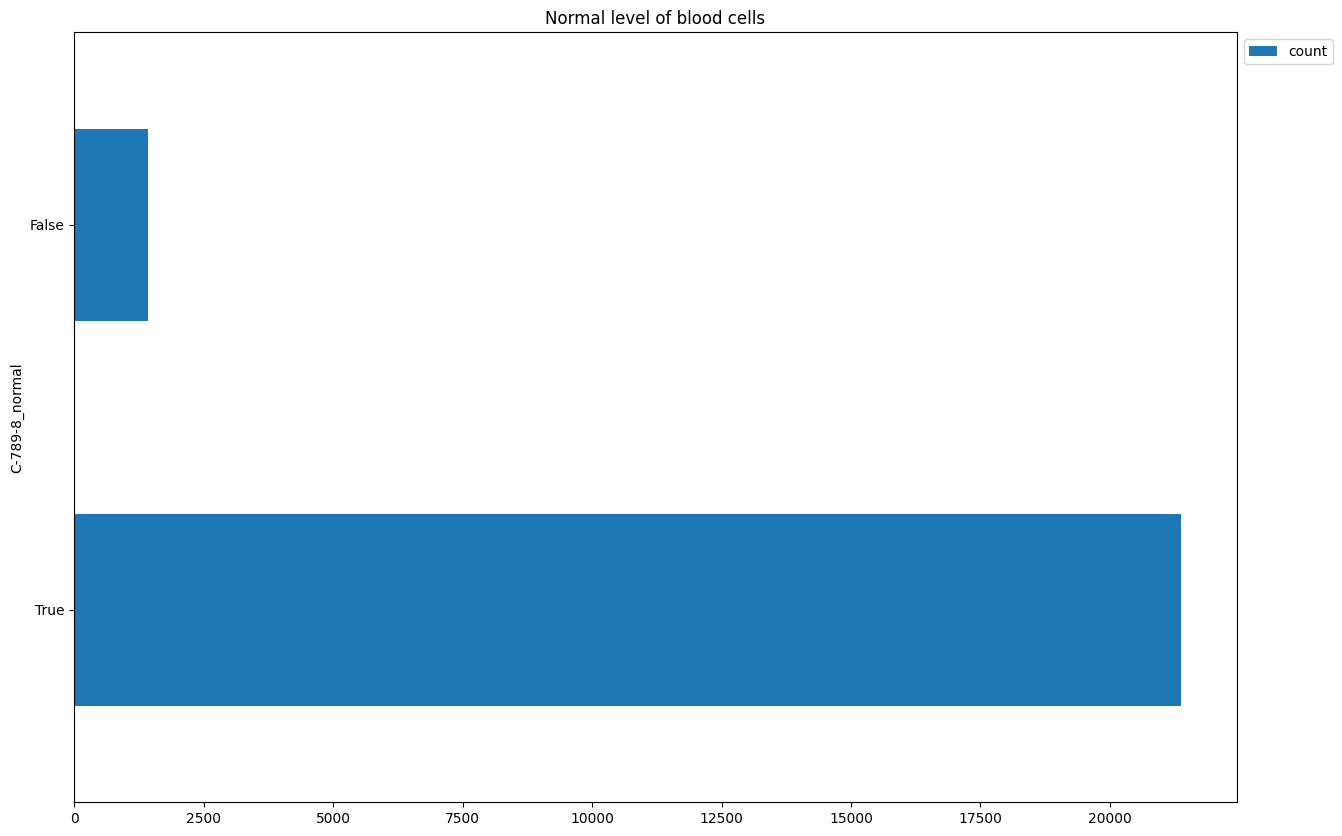

In [44]:
blCellNorm = X['C-789-8_normal'].value_counts().plot(
    kind='barh',
    title="Normal level of blood cells",
    figsize=(15,10)
)

blCellNorm.legend(loc='upper left', bbox_to_anchor=(1,1))

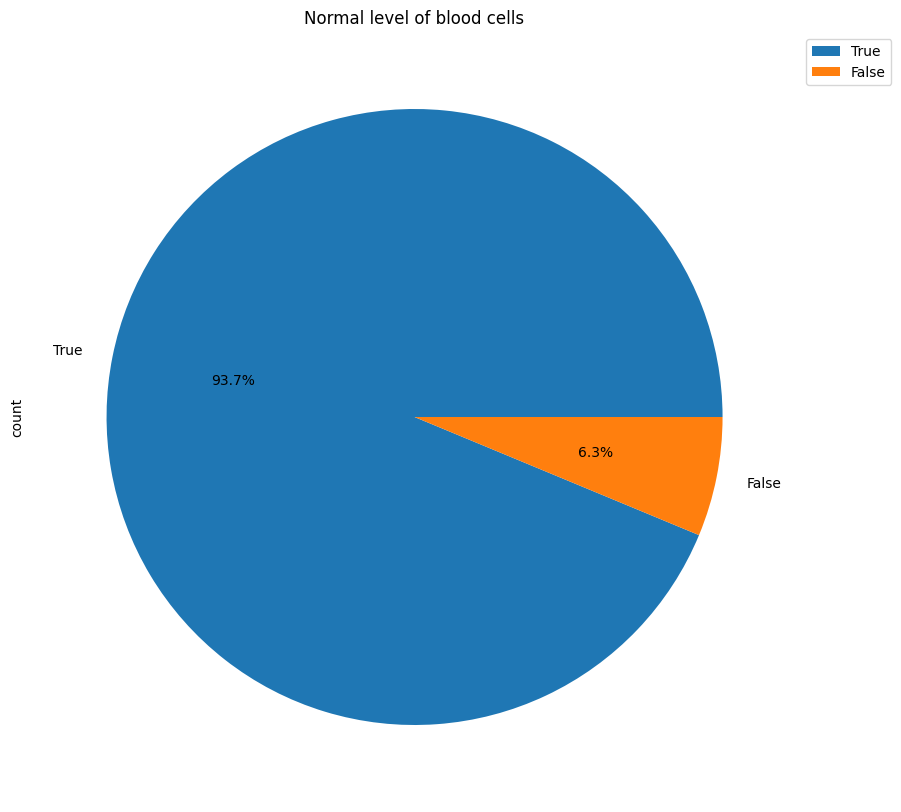

In [45]:
blCellNorm = X['C-789-8_normal'].value_counts().plot(
    kind='pie',
    title="Normal level of blood cells",
    autopct='%1.1f%%',
    figsize=(15,10)
)

blCellNorm.legend(loc='upper left', bbox_to_anchor=(1,1))

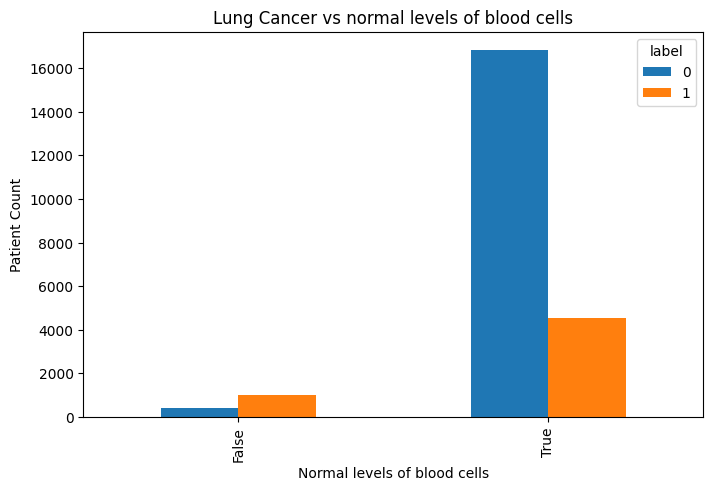

In [46]:
pd.crosstab(
    X['C-789-8_normal'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs normal levels of blood cells")
plt.xlabel("Normal levels of blood cells")
plt.ylabel("Patient Count")
plt.show()

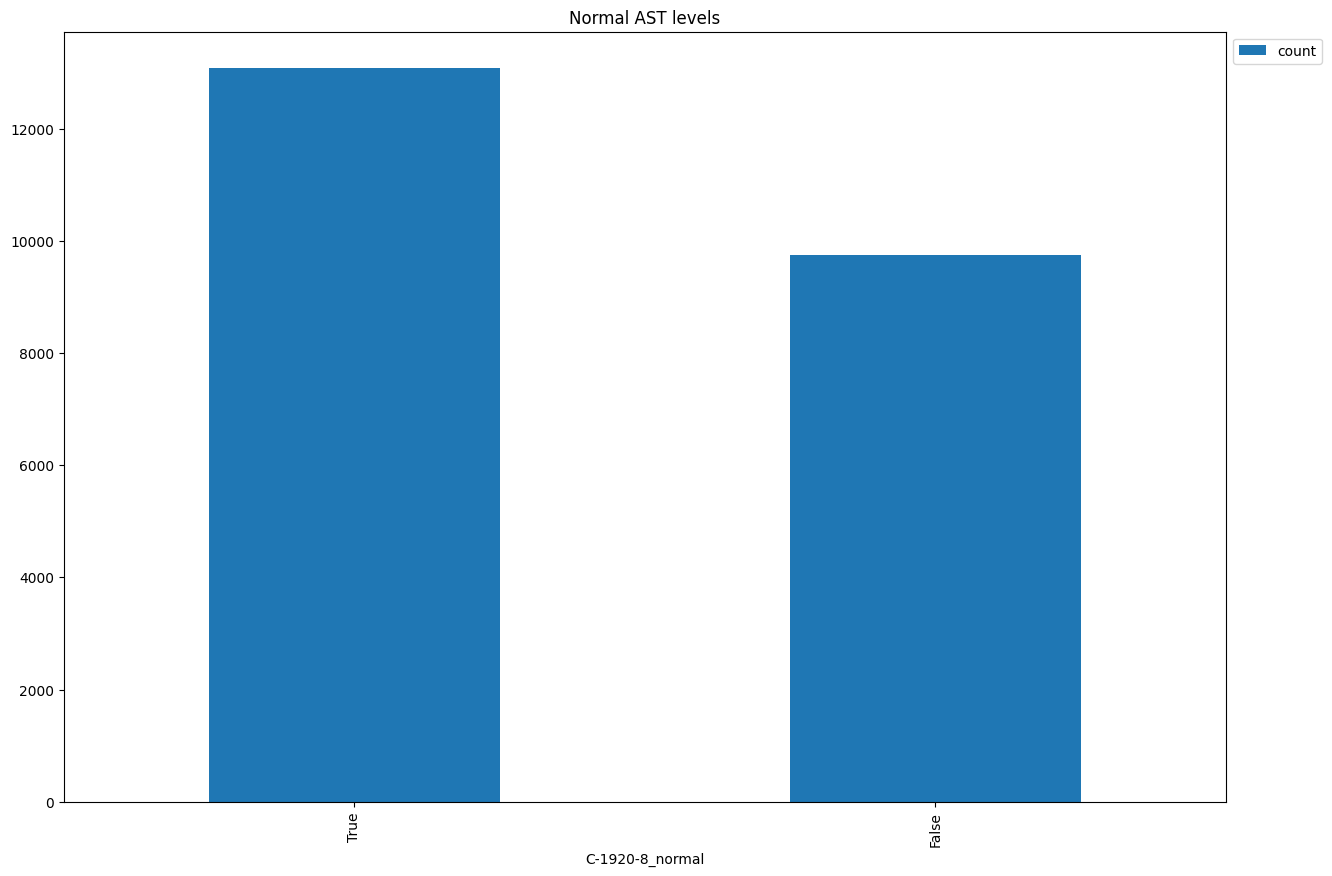

In [47]:
astNorm = X['C-1920-8_normal'].value_counts().plot(
    kind='bar',
    title="Normal AST levels",
    figsize=(15,10)
)

astNorm.legend(loc='upper left', bbox_to_anchor=(1,1))

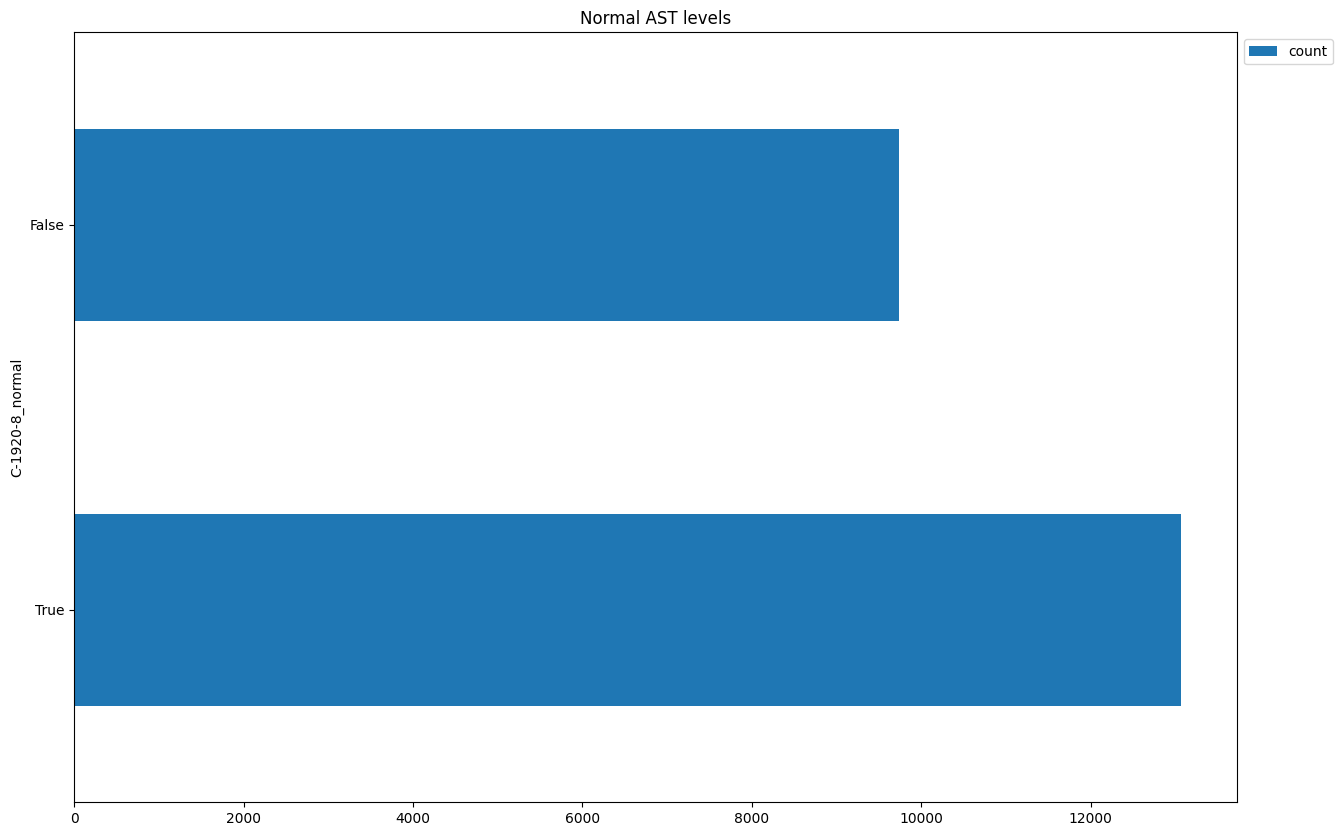

In [48]:
astNorm = X['C-1920-8_normal'].value_counts().plot(
    kind='barh',
    title="Normal AST levels",
    figsize=(15,10)
)

astNorm.legend(loc='upper left', bbox_to_anchor=(1,1))

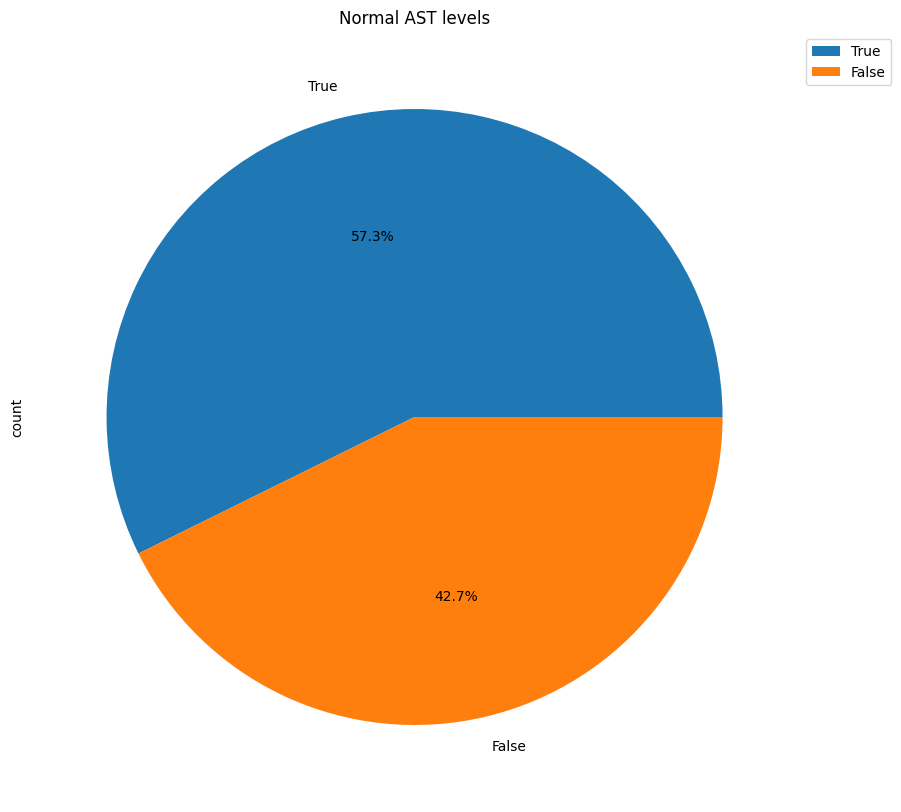

In [49]:
astNorm = X['C-1920-8_normal'].value_counts().plot(
    kind='pie',
    title="Normal AST levels",
    autopct='%1.1f%%',
    figsize=(15,10)
)

astNorm.legend(loc='upper left', bbox_to_anchor=(1,1))

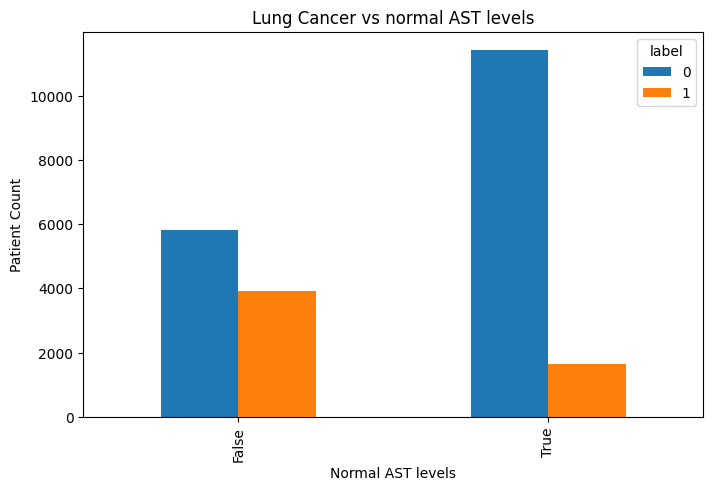

In [50]:
pd.crosstab(
    X['C-1920-8_normal'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs normal AST levels")
plt.xlabel("Normal AST levels")
plt.ylabel("Patient Count")
plt.show()

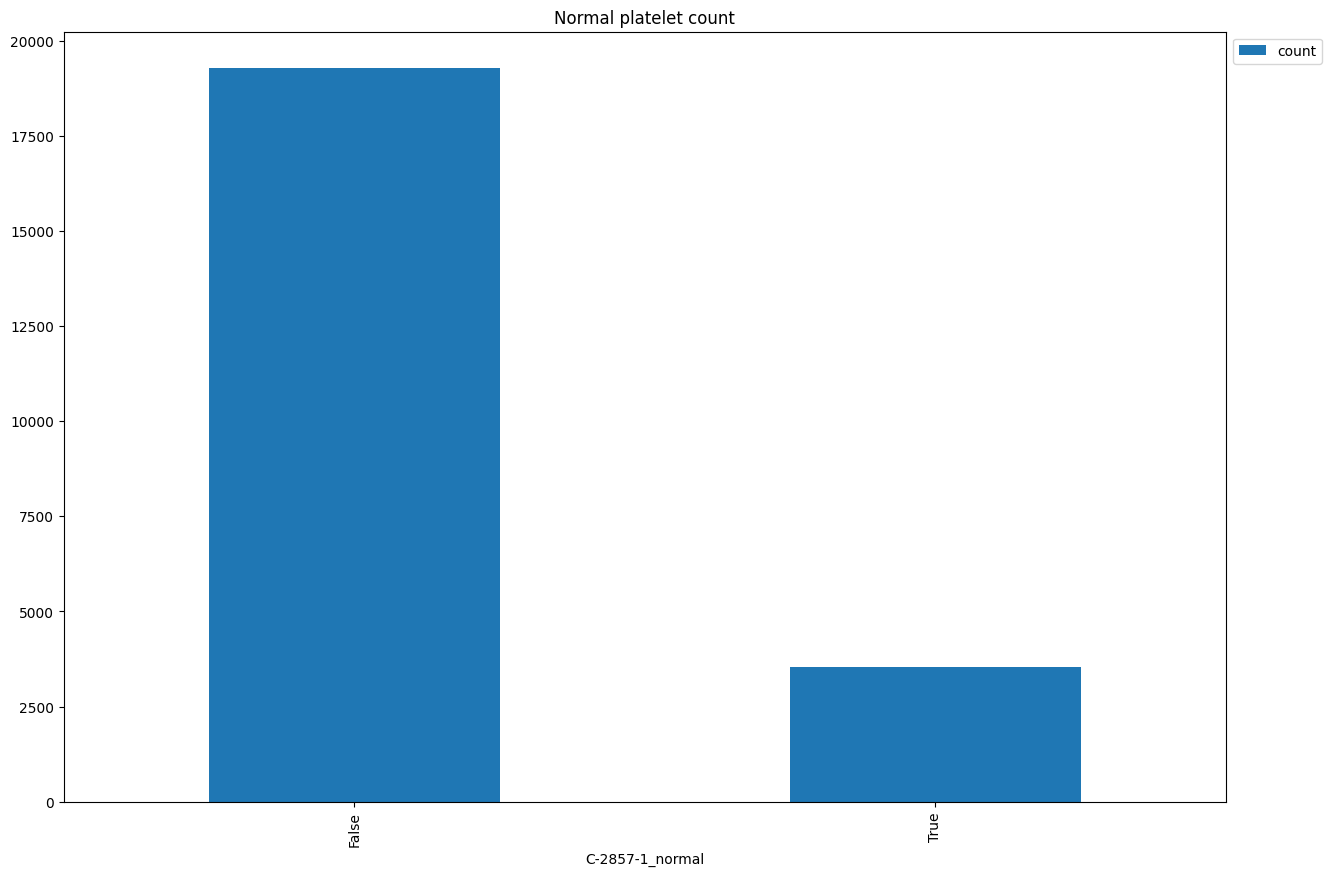

In [51]:
pltNormCt = X['C-2857-1_normal'].value_counts().plot(
    kind='bar',
    title="Normal platelet count",
    figsize=(15,10)
)

pltNormCt.legend(loc='upper left', bbox_to_anchor=(1,1))

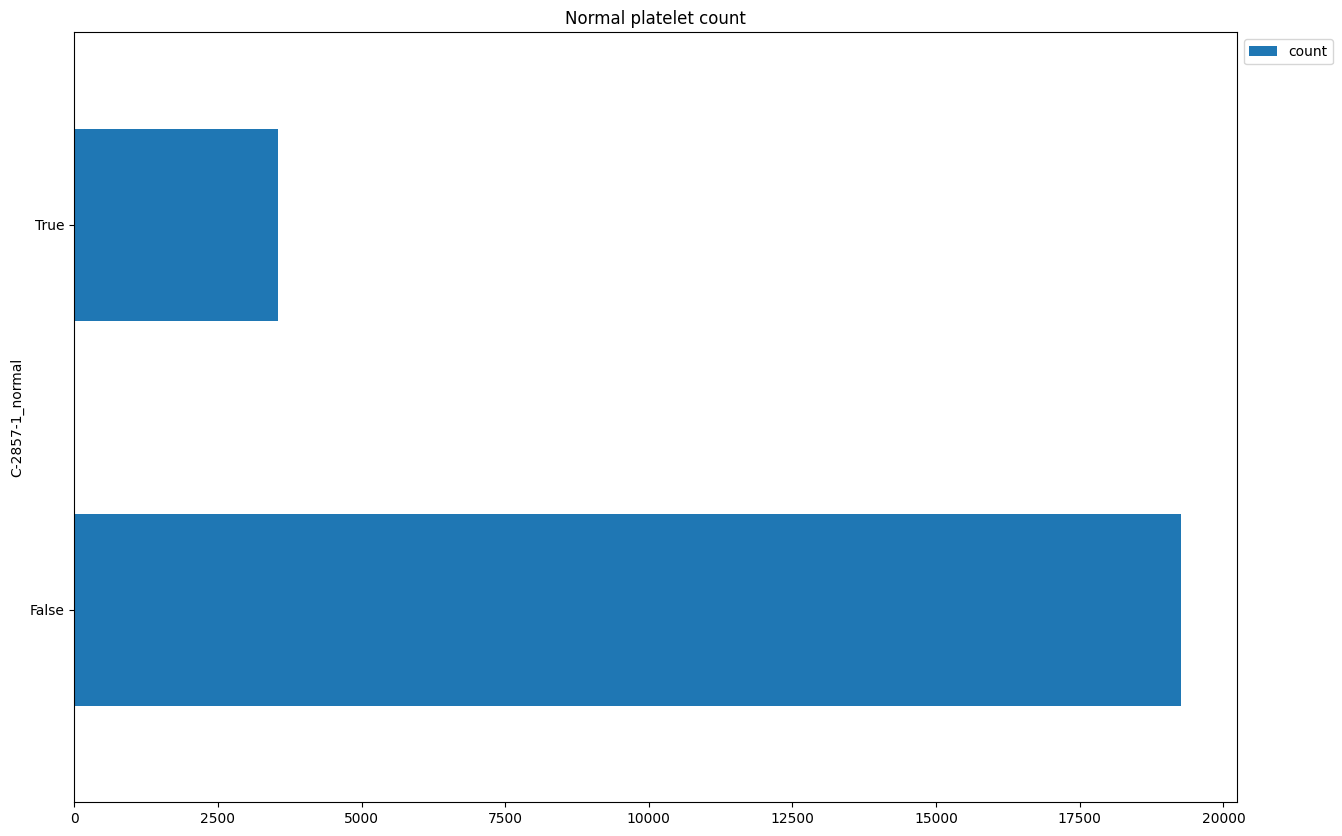

In [52]:
pltNormCt = X['C-2857-1_normal'].value_counts().plot(
    kind='barh',
    title="Normal platelet count",
    figsize=(15,10)
)

pltNormCt.legend(loc='upper left', bbox_to_anchor=(1,1))

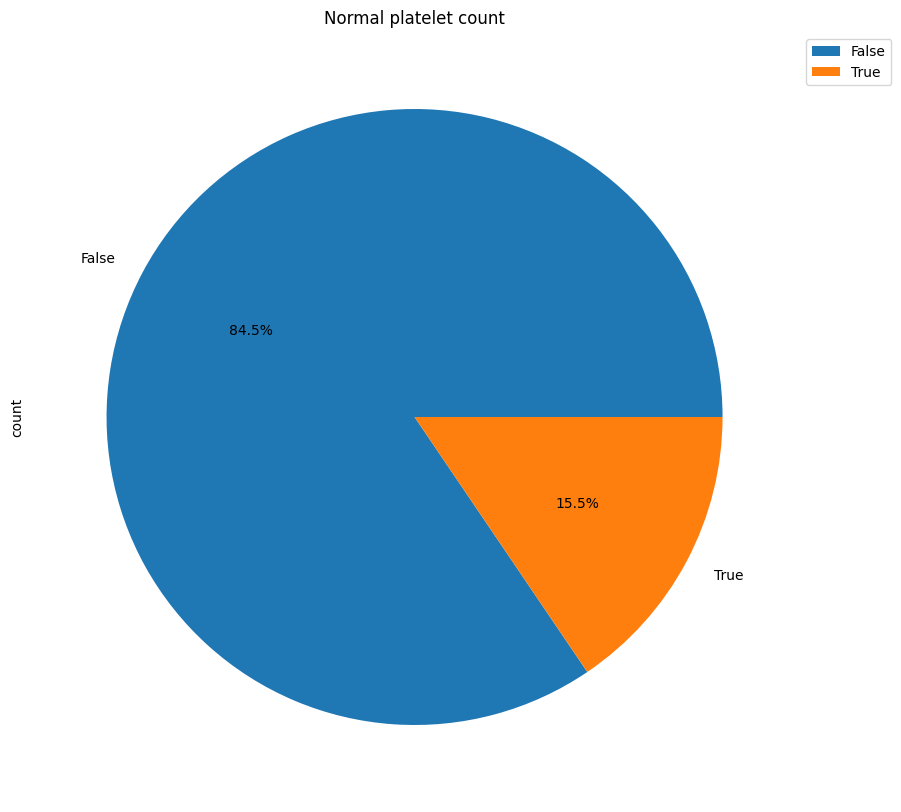

In [53]:
pltNormCt = X['C-2857-1_normal'].value_counts().plot(
    kind='pie',
    title="Normal platelet count",
    autopct='%1.1f%%',
    figsize=(15,10)
)

pltNormCt.legend(loc='upper left', bbox_to_anchor=(1,1))

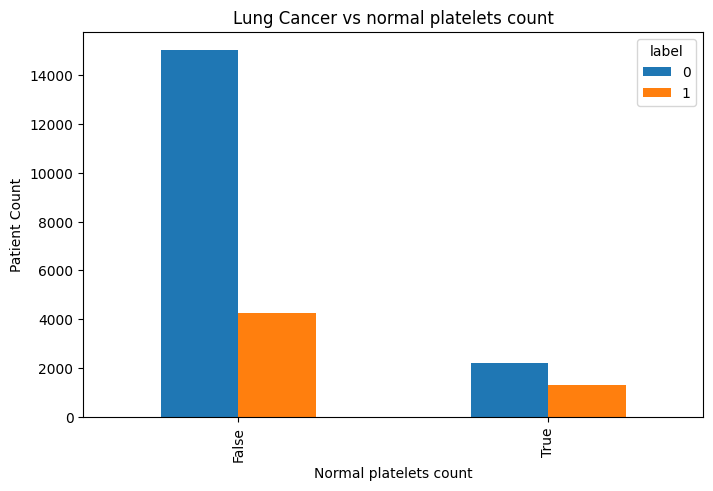

In [54]:
pd.crosstab(
    X['C-2857-1_normal'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs normal platelets count")
plt.xlabel("Normal platelets count")
plt.ylabel("Patient Count")
plt.show()

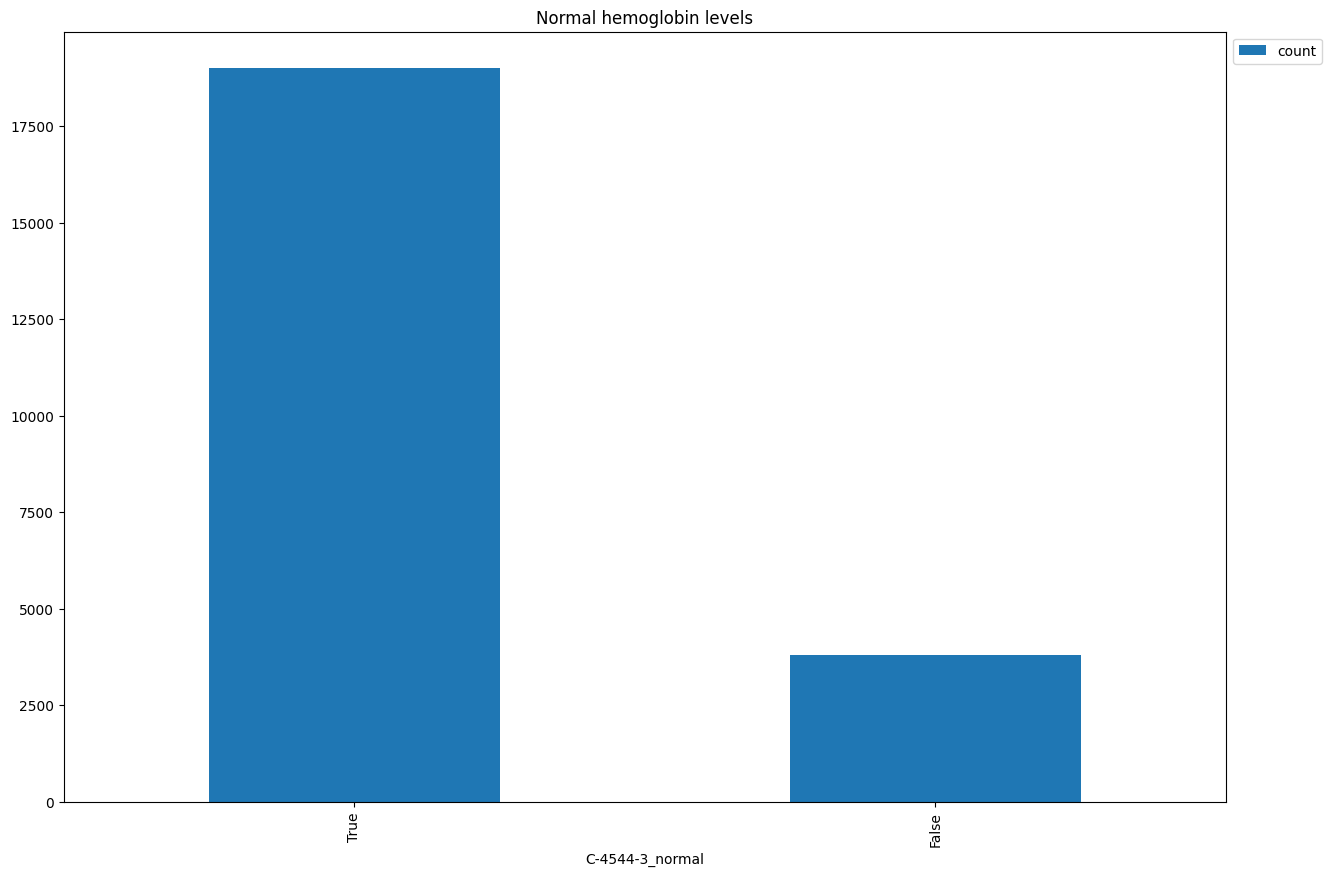

In [55]:
hmglbNorm = X['C-4544-3_normal'].value_counts().plot(
    kind='bar',
    title="Normal hemoglobin levels",
    figsize=(15,10)
)

hmglbNorm.legend(loc='upper left', bbox_to_anchor=(1,1))

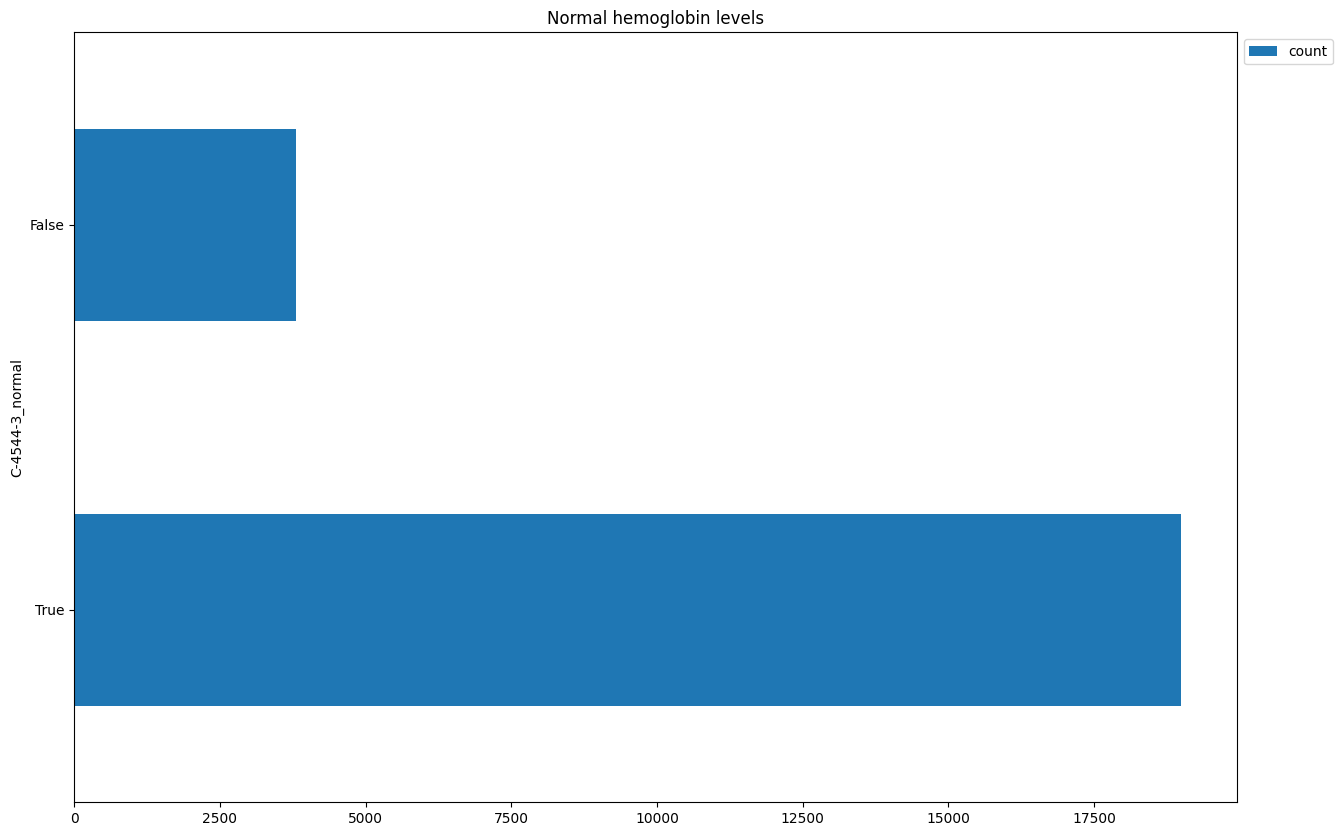

In [56]:
hmglbNorm = X['C-4544-3_normal'].value_counts().plot(
    kind='barh',
    title="Normal hemoglobin levels",
    figsize=(15,10)
)

hmglbNorm.legend(loc='upper left', bbox_to_anchor=(1,1))

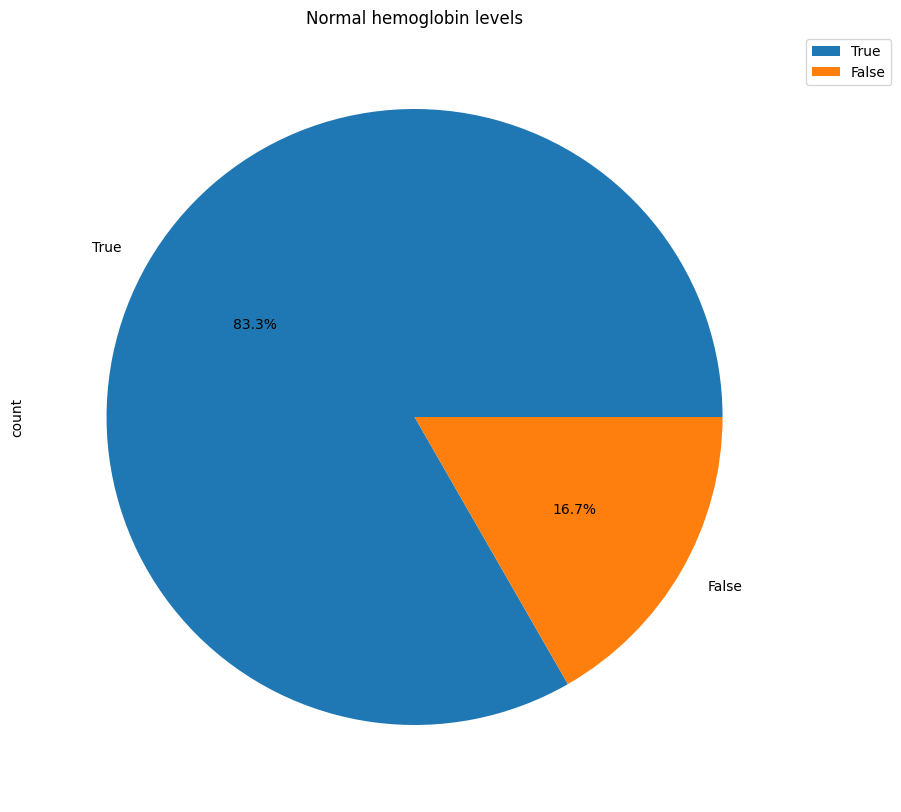

In [57]:
hmglbNorm = X['C-4544-3_normal'].value_counts().plot(
    kind='pie',
    title="Normal hemoglobin levels",
    autopct='%1.1f%%',
    figsize=(15,10)
)

hmglbNorm.legend(loc='upper left', bbox_to_anchor=(1,1))

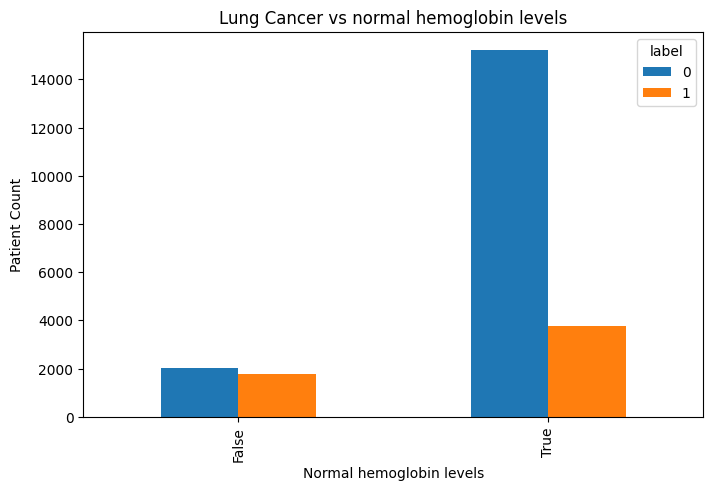

In [58]:
pd.crosstab(
    X['C-4544-3_normal'],
    y
).plot(kind='bar', figsize=(8,5))

plt.title("Lung Cancer vs normal hemoglobin levels")
plt.xlabel("Normal hemoglobin levels")
plt.ylabel("Patient Count")
plt.show()